# **MODULO 1: Analissi de mercado musical para el artista**


**Fuente de datos:** Last.fm API (consumo real de usuarios)  
**Objetivo:** Entender el mercado musical + base para predecir hits  
**Output:** Score de viralidad por canción, tendencias por género y país

* **Datos:**
    * Fuente de datos: Last.fm API (consumo real de usuarios)
    * Datos objetivo: Streams por país, Género musical, Playlist placement, TikTok trends, Crecimiento de artistas similares...
    * EXTRA DATOS: EDAD DE LA AUDIENCIA PARA AVERIGUAR TARGET SEGÚN PLATAFORMA. (MÉTRICAS AUDIENCIA TIK TOK)

* **Análisis (EDA):** crecimiento por género, países con más crecimiento, correlación entre playlist y streams, estacionalidad.
    * Feature Engineering: Ratio energía/valence, duración normalizada, explicit flag, features por artista

* **ML:** Predicción de streams de una canción, Predicción de viralidad, 
    * Modelos: Random Forest, XGBoost, LSTM para series temporales

* Output: “Tu canción tiene 65% probabilidad de viralizarse en México”, “Este beat funciona mejor en playlist de chill trap”




# **DATA from API**

## 0. Imports y Set-up

In [1]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import os
import time
import warnings
warnings.filterwarnings('ignore')

# ── Datos ─────────────────────────────────────────────────────────────────────
import requests
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Configuración de plots ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120,'figure.facecolor': 'white','axes.titlesize': 14,'axes.titleweight': 'bold','axes.labelsize': 11,})
PALETTE = sns.color_palette('coolwarm', 10)

print('Imports correctos')


Imports correctos


## 1. Recopilación de datos API

**Endpoints usados:**

| Endpoint | Datos | Registros objetivo |
|---|---|---|
| `chart.getTopTracks` | Top global (paginado) | ~30.000 |
| `geo.getTopTracks` | Top por país | ~20.000 |
| `tag.getTopTracks` | Top por género/tag | ~15.000 |
| `track.getInfo` | Enriquecimiento (duración, tags) | enriquece los anteriores |

**Conceptos clave de la API:**
- **Throttling** → ir lento a propósito para no superar el rate limit
- **Backoff exponencial** → esperar 2s, 4s, 8s... si hay error
- **Paginación** → iterar por páginas para obtener todos los datos
- **Deduplicación** → eliminar duplicados entre endpoints

DUDA : COMO ASEGURARSE DE CREAR BIEN .env CON GIT IGNORE:
LASTFM_API_KEY='63e059c3c912a3f642daf2372484d183'

In [2]:
# API_KEY = os.getenv('LASTFM_API_KEY') 
API_KEY = '63e059c3c912a3f642daf2372484d183'
BASE_URL = 'http://ws.audioscrobbler.com/2.0/'
DELAY = 0.5  


### Data base para el análisis:

In [3]:
def fetch_lastfm(params: dict, retries: int = 5) -> dict | None:
    """
    Función genérica para llamar a la Last.fm API con retry y backoff exponencial.
    
    Parámetros:
        params   — dict con los parámetros de la petición (method, page, etc.)
        retries  — número máximo de reintentos ante errores de servidor
    
    Retorna el JSON de la respuesta o None si falla definitivamente.
    """
    base_params = {'api_key': API_KEY, 'format': 'json'}
    base_params.update(params)

    for attempt in range(retries):
        try:
            response = requests.get(BASE_URL, params=base_params, timeout=10)

            # Códigos que merecen reintento (server-side errors)
            if response.status_code in [429, 500, 502, 503, 504]:
                wait = 2 ** attempt
                print(f'  ⚠️  HTTP {response.status_code} → retry en {wait}s (intento {attempt+1}/{retries})')
                time.sleep(wait)
                continue

            response.raise_for_status()
            return response.json()

        except requests.exceptions.RequestException as e:
            wait = 2 ** attempt
            print(f'  ⚠️  Error de red: {e} → retry en {wait}s')
            time.sleep(wait)

    print(f'Fallo definitivo tras {retries} intentos')
    return None

* Función data TopTracks

In [4]:
def collect_chart_tracks(n_pages: int = 150, limit: int = 200) -> list[dict]:
    """
    Recoge tracks del ranking global (chart.getTopTracks).
    n_pages=150, limit=200 → objetivo ~30.000 tracks
    """
    tracks = []
    for page in range(1, n_pages + 1):
        data = fetch_lastfm({'method': 'chart.getTopTracks', 'page': page, 'limit': limit})
        if not data:
            break
        page_tracks = data.get('tracks', {}).get('track', [])
        if not page_tracks:
            break
        for t in page_tracks:
            tracks.append({
                'name'       : t.get('name', ''),
                'artist'     : t.get('artist', {}).get('name', '') if isinstance(t.get('artist'), dict) else t.get('artist', ''),
                'playcount'  : t.get('playcount', 0),
                'listeners'  : t.get('listeners', 0),
                'duration'   : t.get('duration', 0),
                'mbid'       : t.get('mbid', ''),
                'country'    : 'GLOBAL',
                'genre_tag'  : 'UNKNOWN',
                'rank_global': (page - 1) * limit + page_tracks.index(t) + 1,
            })
        time.sleep(DELAY)
        if page % 25 == 0:
            print(f'  chart.getTopTracks → página {page}/{n_pages} | tracks acumulados: {len(tracks):,}')
    return tracks

* Funcion de Geo Tracks

In [5]:
def collect_geo_tracks(countries: list[str], pages_per_country: int = 5, limit: int = 200) -> list[dict]:
    """
    Recoge tracks por país (geo.getTopTracks).
    10 países x 5 páginas x 200 tracks → ~10.000 tracks adicionales.
    """
    tracks = []
    for country in countries:
        for page in range(1, pages_per_country + 1):
            data = fetch_lastfm({'method': 'geo.getTopTracks', 'country': country, 'page': page, 'limit': limit})
            if not data:
                break
            page_tracks = data.get('tracks', {}).get('track', [])
            if not page_tracks:
                break
            for t in page_tracks:
                tracks.append({
                    'name'          : t.get('name', ''),
                    'artist'        : t.get('artist', {}).get('name', '') if isinstance(t.get('artist'), dict) else t.get('artist', ''),
                    'playcount'     : t.get('playcount', 0),
                    'listeners'     : t.get('listeners', 0),
                    'duration'      : t.get('duration', 0),
                    'mbid'          : t.get('mbid', ''),
                    'country'       : country,
                    'genre_tag'     : 'UNKNOWN',
                    'rank_by_country': (page - 1) * limit + page_tracks.index(t) + 1,
                })
            time.sleep(DELAY)
        print(f'  geo.getTopTracks [{country}] → {len([t for t in tracks if t["country"]==country]):,} tracks')
    return tracks

* Funcion de tag tracks

In [6]:
def collect_tag_tracks(tags: list[str], pages_per_tag: int = 10, limit: int = 200) -> list[dict]:
    """
    Recoge tracks por género/tag (tag.getTopTracks).
    10 tags x 10 páginas x 200 tracks → ~20.000 tracks adicionales.
    """
    tracks = []
    for tag in tags:
        for page in range(1, pages_per_tag + 1):
            data = fetch_lastfm({'method': 'tag.getTopTracks', 'tag': tag, 'page': page, 'limit': limit})
            if not data:
                break
            page_tracks = data.get('tracks', {}).get('track', [])
            if not page_tracks:
                break
            for t in page_tracks:
                tracks.append({
                    'name'      : t.get('name', ''),
                    'artist'    : t.get('artist', {}).get('name', '') if isinstance(t.get('artist'), dict) else t.get('artist', ''),
                    'playcount' : t.get('playcount', 0),
                    'listeners' : t.get('listeners', 0),
                    'duration'  : t.get('duration', 0),
                    'mbid'      : t.get('mbid', ''),
                    'country'   : 'UNKNOWN',
                    'genre_tag' : tag,
                })
            time.sleep(DELAY)
        print(f'  tag.getTopTracks [{tag}] → {len([t for t in tracks if t["genre_tag"]==tag]):,} tracks')
    return tracks

* Parametros de recoleccion:

In [7]:
# ── Parámetros de recolección ─────────────────────────────────────────────────
COUNTRIES = ['Spain', 'United States', 'United Kingdom', 'Brazil', 'Germany', 'France', 'Mexico', 'Peru', 'Japan', 'Chile']

TAGS = ['rock', 'electronic', 'seen live', 'alternative', 'pop', 'female vocalists', 'metal', 'jazz', 'classic rock', 'ambient', 'experimental', 'folk', 'punk', 'Hip-Hop', 'instrumental', 'singer-songwriter']

# ── Recolección (solo ejecutar si no tenemos CSV guardado) ────────────────────
CSV_PATH = 'lastfm_dataset.csv'

if os.path.exists(CSV_PATH):
    print(f'📂 CSV existente encontrado: {CSV_PATH}')
    df_raw = pd.read_csv(CSV_PATH, low_memory=False)
    print(f'   Filas cargadas: {len(df_raw):,}')
else:
    print('🚀 Iniciando recolección multi-endpoint...')
    all_tracks = []

    print('\n[1/3] chart.getTopTracks (global)')
    all_tracks += collect_chart_tracks(n_pages=150)

    print('\n[2/3] geo.getTopTracks (por país)')
    all_tracks += collect_geo_tracks(COUNTRIES, pages_per_country=10)

    print('\n[3/3] tag.getTopTracks (por género)')
    all_tracks += collect_tag_tracks(TAGS, pages_per_tag=10)

    df_raw = pd.DataFrame(all_tracks)
    df_raw.to_csv(CSV_PATH, index=False)
    print(f'\n✅ Recolección completa. Total tracks: {len(df_raw):,}')
    print(f'   Guardado en: {CSV_PATH}')

print(f'\nForma del dataset: {df_raw.shape}')
df_raw.head(3)

📂 CSV existente encontrado: lastfm_dataset.csv


   Filas cargadas: 59,999

Forma del dataset: (59999, 10)


,name,artist,playcount,listeners,duration,mbid,country,genre_tag,rank_global,rank_by_country
0,Stateside + Zara Larsson,PinkPantheress,14935083,1021197,176,ffbf7862-2476-4164-ac32-f5904ccefe0f,GLOBAL,UNKNOWN,1.0,NaN
1,Body to Body,BTS,3856998,266462,189,6dfdfc61-89ff-451a-a5e9-5319065beae7,GLOBAL,UNKNOWN,2.0,NaN
2,Swim,BTS,9268750,250573,159,6f33dc05-cdc0-4a2f-8039-e8fed082eec6,GLOBAL,UNKNOWN,3.0,NaN


In [8]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 59999 entries, 0 to 59998
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             59999 non-null  str    
 1   artist           59999 non-null  str    
 2   playcount        59999 non-null  int64  
 3   listeners        59999 non-null  int64  
 4   duration         59999 non-null  int64  
 5   mbid             53294 non-null  str    
 6   country          59999 non-null  str    
 7   genre_tag        59999 non-null  str    
 8   rank_global      9999 non-null   float64
 9   rank_by_country  20000 non-null  float64
dtypes: float64(2), int64(3), str(5)
memory usage: 4.6 MB


Errores:

| Código | Significado | Quién tiene el problema     |
| ------ | ----------- | --------------------------- |
| 403    | Forbidden   | ❌ tú (API key, permisos)    |
| 429    | Rate limit  | ⚠️ tú (demasiadas requests) |
| 502    | Bad Gateway | ❌ servidor (Last.fm)        |


# **EDA**

## Información general:

1. **Análisis del mercado musical (descriptivo):** (1) Top canciones / artistas por periodo (tiempo); (2) Evolución temporal de popularidad; (3) Géneros en crecimiento vs decrecimiento

2. **Análisis por género:**

* Distribución de features por género: danceability, energy, valence, tempo

* ¿Qué hace único a cada género?

3. **Análisis geográfico** (1) Países con mayor consumo; (2) Diferencias culturales en features.

4. **Ciclos de éxito:** (1) Duración de popularidad de una canción; (2) Tiempo entre picos de streams; (3) Estacionalidad (ej: “hits de verano”)

**Features engineering (clave para predecir un hit):**


1. **Correlación con popularidad:** Qué variables impactan más: danceability ↑, energy ↑, valence (positivo vs triste)

* Heatmap de correlaciones

2. **Ingeniería de variables:** (1) Ratio energía/valence; (2) Duración normalizada; (3) Explicit vs no explicit; (4) Features agregadas por artista

3. **Segmentación de canciones:** 

* Clustering para KMeans
* Tipos de canciones: “club hit”, “chill”, “sad viral”,... 


## 1. **Limpieza de datos**

In [9]:
# ── Tipos correctos ───────────────────────────────────────────────────────
df = df_raw.copy()

# Convertir a numérico (valores no numéricos → NaN)
for col in ['playcount', 'listeners', 'duration']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Strings limpios
for col in ['name', 'artist', 'country', 'genre_tag']:
    df[col] = df[col].astype(str).str.strip()

print('✅ Tipos convertidos')
df.dtypes

✅ Tipos convertidos


name                   str
artist                 str
playcount            int64
listeners            int64
duration             int64
mbid                   str
country                str
genre_tag              str
rank_global        float64
rank_by_country    float64
dtype: object

* Valores nulos e inconsistencias:

In [10]:
print('Nulos antes de limpiar:')
print(df.isnull().sum())


Nulos antes de limpiar:
name                   0
artist                 0
playcount              0
listeners              0
duration               0
mbid                6705
country                0
genre_tag              0
rank_global        50000
rank_by_country    39999
dtype: int64


In [11]:
df = df.dropna(subset=['name', 'artist']) # Eliminar filas sin nombre ni artista (sin estas columnas el track no tiene identidad)

# Duración: 0 y NaN son equivalentes aquí → rellenar con mediana
df['duration'] = df['duration'].replace(0, np.nan)
df['duration'] = df['duration'].fillna(df['duration'].median())

# Tags y países unknown: los dejamos como 'UNKNOWN' (son una categoría válida)
df['genre_tag'] = df['genre_tag'].replace(['', 'nan', 'None'], 'UNKNOWN')
df['country']   = df['country'].replace(['', 'nan', 'None'], 'UNKNOWN')

print(f'\nFilas tras limpiar: {len(df):,}')


Filas tras limpiar: 59,999


* Duplicados:

In [12]:
# Si un mismo track aparece en múltiples endpoints, nos quedamos con el que
# tiene el mayor playcount (es el dato más completo)
before = len(df)
df = (
    df.sort_values('playcount', ascending=False)
    .drop_duplicates(subset=['name', 'artist'], keep='first')
    .reset_index(drop=True)
)
print(f'Deduplicación: {before:,} → {len(df):,} tracks únicos ({before - len(df):,} duplicados eliminados)')

Deduplicación: 59,999 → 35,056 tracks únicos (24,943 duplicados eliminados)


## 2. **Future engineering**

In [13]:
# ── Crear las 20 columnas del proyecto ───────────────────

# --- Features derivadas de negocio ---

# Ratio de engagement: oyentes que escuchan más de una vez
# Cuanto más alto, más 'fidelizante' es la canción
df['playcount_per_listener'] = df['playcount'] / df['listeners'].replace(0, np.nan)

# Duración en minutos (más legible que milisegundos)
df['duration_min'] = df['duration'] / 60000

# Flag canciones cortas (<2.5 min) — formato TikTok/Reels
df['is_short_track'] = (df['duration_min'] < 2.5).astype(int)

# --- Transformaciones logarítmicas ---
# Playcount y listeners tienen distribución muy sesgada a la derecha.
# log1p(x) = log(1+x) → comprime la escala, mejora modelos ML
df['playcount_log'] = np.log1p(df['playcount'])
df['listeners_log'] = np.log1p(df['listeners'])

# --- Rankings ---
if 'rank_global' not in df.columns:
    df['rank_global'] = df['playcount'].rank(ascending=False, method='min').astype(int)

if 'rank_by_country' not in df.columns:
    df['rank_by_country'] = (
        df.groupby('country')['playcount']
        .rank(ascending=False, method='min')
        .astype(int)
    )

# --- Simulación temporal para análisis de series ---
# No tenemos fechas reales en Last.fm chart. Estrategia:
# Asignamos una 'cohort' simulada basada en el rank global.
# Lógica: canciones con rank alto son más recientes (en tendencia hoy)
# Las del fondo del ranking llevan más tiempo en la plataforma.
# Dividimos en 12 meses (el año 2024 completo).
n_tracks = len(df)
df['simulated_rank_percentile'] = df['rank_global'].rank(pct=True)  # 0 a 1
df['month_cohort'] = pd.cut(
    df['simulated_rank_percentile'],
    bins=12,
    labels=[f'2024-{m:02d}' for m in range(1, 13)]
)

# --- Features de artista (agregadas) ---
# Cuántas canciones del dataset tiene cada artista
artist_stats = df.groupby('artist').agg(
    artist_track_count=('name', 'count'),
    artist_total_playcount=('playcount', 'sum'),
    artist_avg_playcount=('playcount', 'mean'),
).reset_index()
df = df.merge(artist_stats, on='artist', how='left')

# Peso relativo del hit: qué % del total de plays del artista son de esta canción
df['track_share_of_artist'] = df['playcount'] / df['artist_total_playcount'].replace(0, np.nan)

# --- Columnas de API enriquecida (si existen del pipeline) ---
for col in ['artist_listeners', 'artist_playcount', 'similar_artists_count', 'track_duration_ms']:
    if col not in df.columns:
        df[col] = np.nan  # placeholder hasta enriquecer desde track.getInfo

# --- Fecha de colección ---
df['collection_date'] = pd.Timestamp.today().normalize()

print(f'✅ Feature engineering completo')
print(f'   Columnas totales: {len(df.columns)}')
print(f'   Columnas: {list(df.columns)}')

✅ Feature engineering completo
   Columnas totales: 26
   Columnas: ['name', 'artist', 'playcount', 'listeners', 'duration', 'mbid', 'country', 'genre_tag', 'rank_global', 'rank_by_country', 'playcount_per_listener', 'duration_min', 'is_short_track', 'playcount_log', 'listeners_log', 'simulated_rank_percentile', 'month_cohort', 'artist_track_count', 'artist_total_playcount', 'artist_avg_playcount', 'track_share_of_artist', 'artist_listeners', 'artist_playcount', 'similar_artists_count', 'track_duration_ms', 'collection_date']


* df_clean final

In [14]:
# Seleccionamos y ordenamos las 20 columnas del diseño del proyecto
COLUMNS_20 = [
    # Columnas base
    'name', 'artist', 'playcount', 'listeners', 'duration',
    'country', 'genre_tag',
    # Features derivadas
    'playcount_per_listener', 'duration_min', 'is_short_track',
    'playcount_log', 'listeners_log',
    # Rankings
    'rank_global', 'rank_by_country',
    # Artista
    'artist_track_count', 'artist_total_playcount', 'track_share_of_artist',
    # Temporal simulada
    'month_cohort',
    # Metadatos
    'collection_date',
    # API enriquecida (puede ser NaN hasta enriquecer)
    'similar_artists_count',
]

df_clean = df[COLUMNS_20].copy()

# Guardar el dataset limpio
df_clean.to_csv('lastfm_clean.csv', index=False)

print('\nDataset limpio — resumen:')
print(f'Filas: {len(df_clean):,}  |  Columnas: {len(df_clean.columns)}')
display(df_clean.head(5))
print('\nEstadísticas descriptivas:')
display(df_clean.describe())


Dataset limpio — resumen:
Filas: 35,056  |  Columnas: 20


,name,artist,playcount,listeners,duration,country,genre_tag,playcount_per_listener,duration_min,is_short_track,playcount_log,listeners_log,rank_global,rank_by_country,artist_track_count,artist_total_playcount,track_share_of_artist,month_cohort,collection_date,similar_artists_count
0,Don’t Say You Love Me,Jin,282096112,256078,180.0,GLOBAL,UNKNOWN,1101.602293,0.003000,1,19.457758,12.453241,297.0,NaN,22,774521880,0.364220,2024-01,2026-03-23,NaN
1,Who,Jimin,239767776,462313,170.0,GLOBAL,UNKNOWN,518.626506,0.002833,1,19.295181,13.044000,241.0,NaN,17,542802676,0.441722,2024-01,2026-03-23,NaN
2,Haegeum,Agust D,230167563,406229,168.0,GLOBAL,UNKNOWN,566.595598,0.002800,1,19.254318,12.914675,279.0,NaN,29,558934162,0.411797,2024-01,2026-03-23,NaN
3,Dynamite,BTS,173756636,1055844,199.0,GLOBAL,UNKNOWN,164.566580,0.003317,1,18.973166,13.869852,175.0,NaN,249,2945105856,0.058998,2024-01,2026-03-23,NaN
4,Standing Next to You,Jung Kook,173643884,743754,206.0,GLOBAL,UNKNOWN,233.469513,0.003433,1,18.972517,13.519467,295.0,NaN,20,730023390,0.237861,2024-01,2026-03-23,NaN



Estadísticas descriptivas:


,playcount,listeners,duration,playcount_per_listener,duration_min,is_short_track,playcount_log,listeners_log,rank_global,rank_by_country,artist_track_count,artist_total_playcount,track_share_of_artist,collection_date,similar_artists_count
count,3.505600e+04,3.505600e+04,35056.000000,13743.000000,35056.000000,35056.0,35056.000000,35056.000000,9982.000000,3761.000000,35056.000000,3.505600e+04,20677.000000,35056,0.0
mean,2.117307e+06,1.718016e+05,241.309105,9.545303,0.004022,1.0,4.371828,4.364036,5007.654578,1116.621643,31.284117,1.177396e+08,0.111283,2026-03-23 00:00:00,NaN
min,0.000000e+00,0.000000e+00,11.000000,0.000000,0.000183,1.0,0.000000,0.000000,1.000000,3.000000,1.000000,0.000000e+00,0.000000,2026-03-23 00:00:00,NaN
25%,0.000000e+00,0.000000e+00,188.000000,0.000000,0.003133,1.0,0.000000,0.000000,2513.250000,658.000000,5.000000,0.000000e+00,0.000000,2026-03-23 00:00:00,NaN
50%,0.000000e+00,0.000000e+00,221.000000,8.472114,0.003683,1.0,0.000000,0.000000,5008.500000,1177.000000,16.000000,6.078623e+06,0.000000,2026-03-23 00:00:00,NaN
75%,1.554757e+06,1.575132e+05,267.000000,12.308289,0.004450,1.0,14.256830,11.967271,7503.750000,1603.000000,40.000000,6.071852e+07,0.063067,2026-03-23 00:00:00,NaN
max,2.820961e+08,4.032672e+06,12075.000000,1101.602293,0.201250,1.0,19.457758,15.209940,9999.000000,2000.000000,270.000000,3.001553e+09,1.000000,2026-03-23 00:00:00,NaN
std,6.021686e+06,3.739498e+05,138.638024,19.435707,0.002311,0.0,6.953209,5.784305,2883.091040,564.559330,42.031087,3.911711e+08,0.255054,NaN,NaN


# **EDA**

## 1. Listas Top

### Top 15 canciones globales por playcount 


**Objetivo:** identificar qué canciones y artistas dominan el mercado y si ese dominio varía según el periodo (cohort mensual simulado).

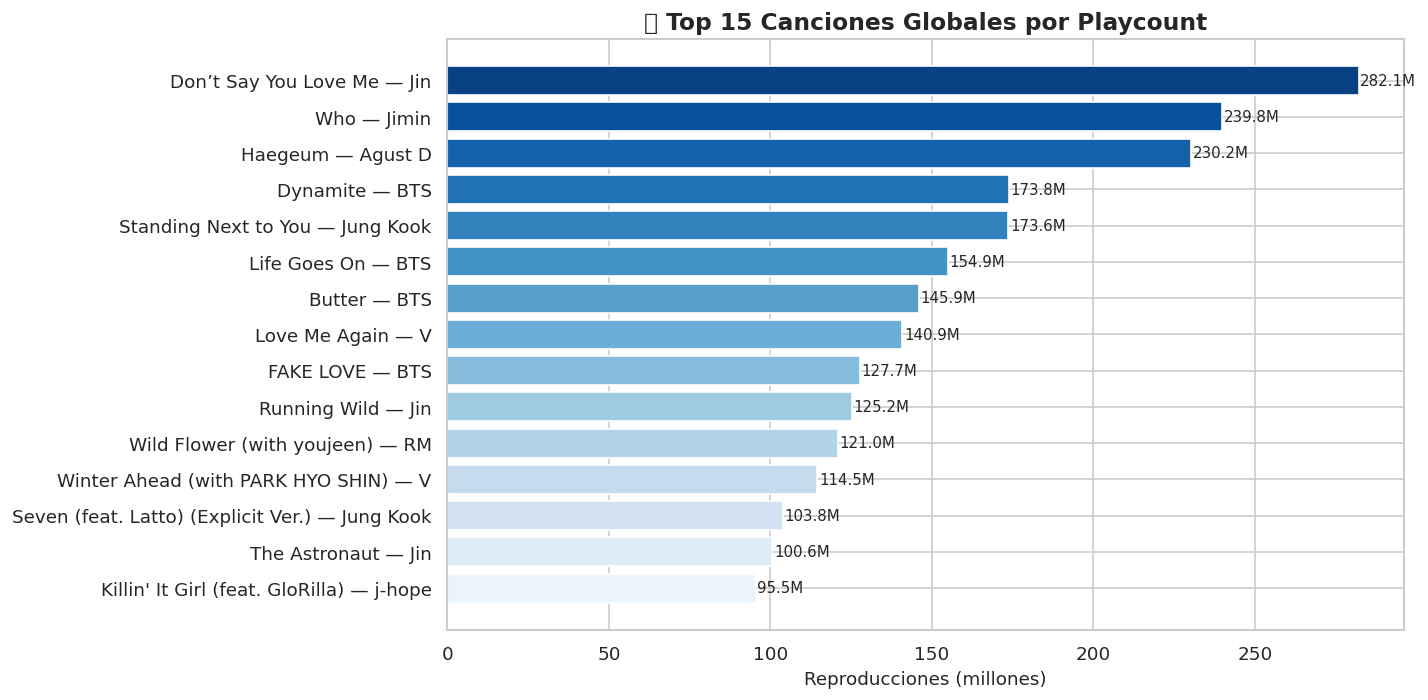


💡 Insight: La canción más reproducida es "Don’t Say You Love Me" de Jin con 282.1M reproducciones.
   Ratio de engagement: 1101.6x (cada oyente la escucha 1102 veces de media)


In [15]:
top15_tracks = (
    df_clean
    .sort_values('playcount', ascending=False)
    .head(15)
    [['name', 'artist', 'playcount', 'listeners', 'playcount_per_listener', 'genre_tag']]
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top15_tracks['name'] + ' — ' + top15_tracks['artist'],
    top15_tracks['playcount'] / 1e6,
    color=sns.color_palette('Blues_r', 15)
)
ax.set_xlabel('Reproducciones (millones)')
ax.set_title('🏆 Top 15 Canciones Globales por Playcount')
ax.invert_yaxis()

# Etiquetas con millones
for bar, val in zip(bars, top15_tracks['playcount']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_top15_tracks.png', bbox_inches='tight')
plt.show()

# Insight
top1 = top15_tracks.iloc[0]
print(f'\n💡 Insight: La canción más reproducida es "{top1["name"]}" de {top1["artist"]}'
      f' con {top1["playcount"]/1e6:.1f}M reproducciones.')
print(f'   Ratio de engagement: {top1["playcount_per_listener"]:.1f}x '
      f'(cada oyente la escucha {top1["playcount_per_listener"]:.0f} veces de media)')

### Top 15 artistas por oyentes totales

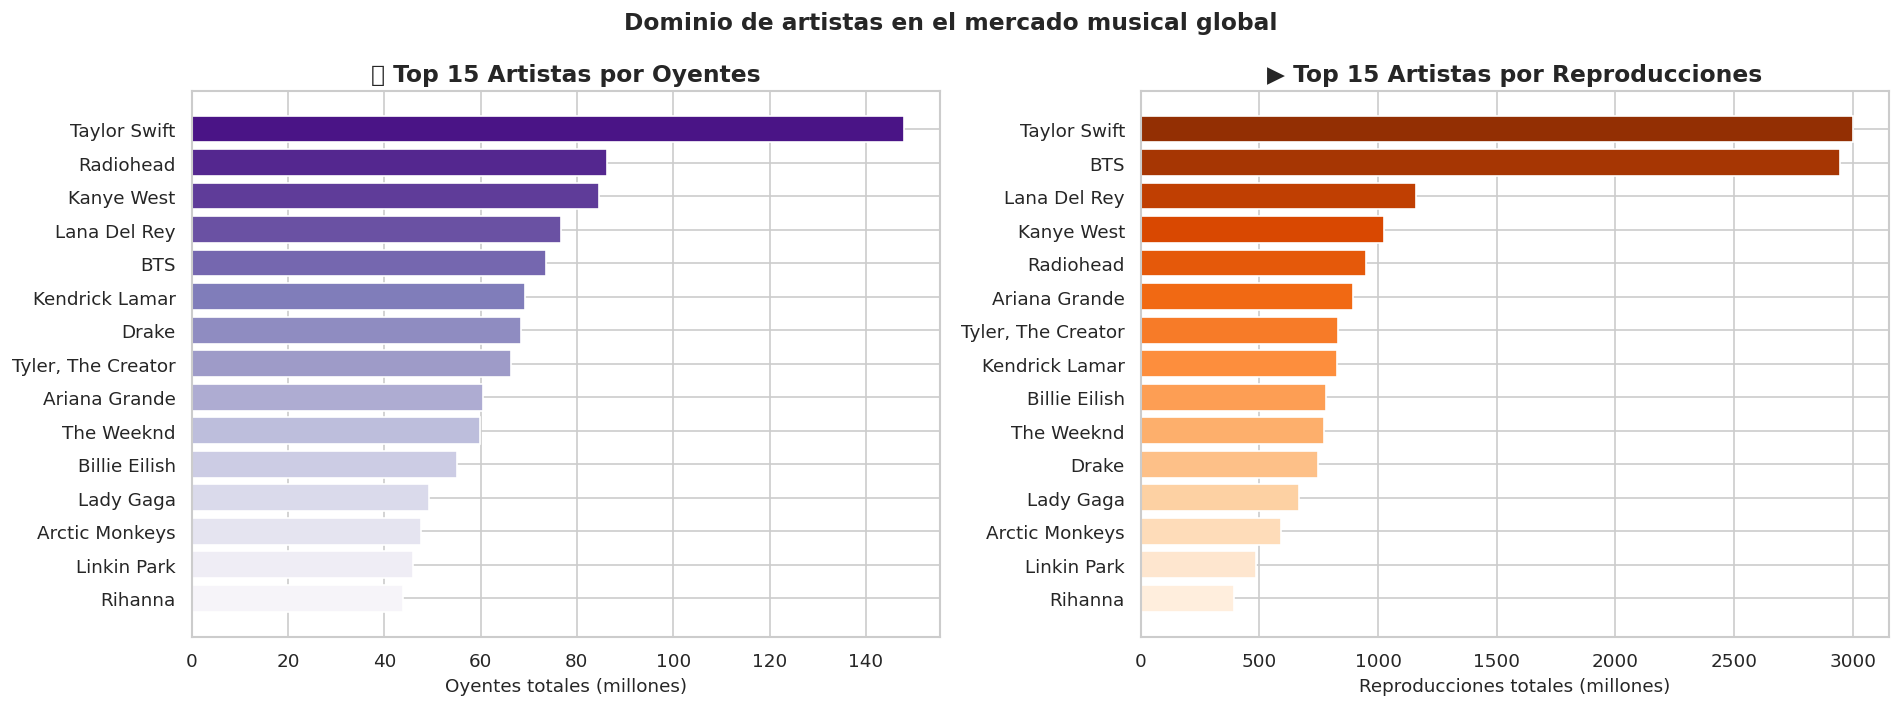


💡 Insight: Taylor Swift es el artista con más oyentes (147.9M) y 270 canciones en el dataset.


In [16]:
top15_artists = (
    df_clean
    .groupby('artist')
    .agg(
        total_plays=('playcount', 'sum'),
        total_listeners=('listeners', 'sum'),
        n_tracks=('name', 'count'),
        avg_engagement=('playcount_per_listener', 'mean')
    )
    .sort_values('total_listeners', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por oyentes
axes[0].barh(top15_artists['artist'], top15_artists['total_listeners'] / 1e6,
             color=sns.color_palette('Purples_r', 15))
axes[0].invert_yaxis()
axes[0].set_xlabel('Oyentes totales (millones)')
axes[0].set_title('👤 Top 15 Artistas por Oyentes')

# Por reproducciones
top15_plays = top15_artists.sort_values('total_plays', ascending=False)
axes[1].barh(top15_plays['artist'], top15_plays['total_plays'] / 1e6,
             color=sns.color_palette('Oranges_r', 15))
axes[1].invert_yaxis()
axes[1].set_xlabel('Reproducciones totales (millones)')
axes[1].set_title('▶️ Top 15 Artistas por Reproducciones')

plt.suptitle('Dominio de artistas en el mercado musical global', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_top15_artists.png', bbox_inches='tight')
plt.show()

# Insight
top_artist = top15_artists.iloc[0]
print(f'\n💡 Insight: {top_artist["artist"]} es el artista con más oyentes '
      f'({top_artist["total_listeners"]/1e6:.1f}M) y '
      f'{top_artist["n_tracks"]} canciones en el dataset.')

### Top artistas por cohort mensual


* Para cada mes simulado, cuál es el artista con más reproducciones

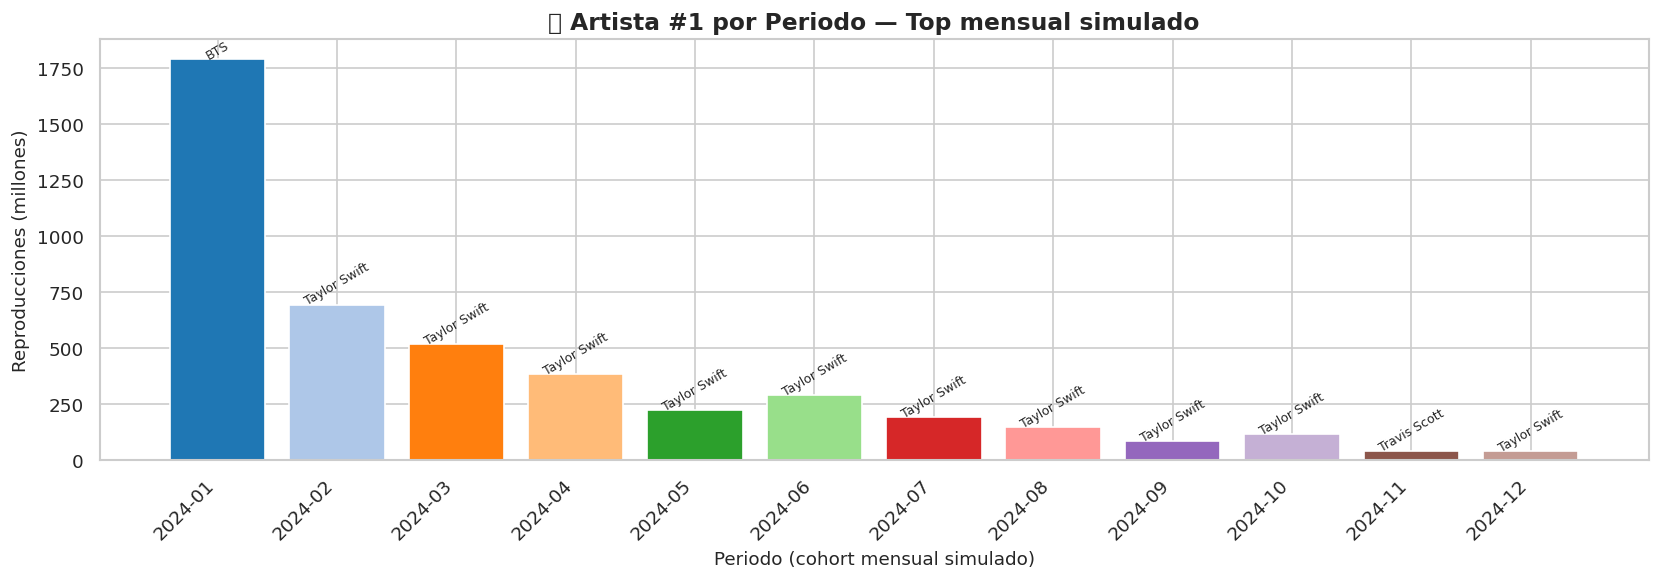

⚠️  Nota metodológica: los periodos son cohorts simulados basados en rank global,
    no fechas reales de streaming. Reflejan la "antigüedad" relativa en el ranking.


In [17]:

top_by_month = (
    df_clean
    .groupby(['month_cohort', 'artist'])['playcount']
    .sum()
    .reset_index()
    .sort_values(['month_cohort', 'playcount'], ascending=[True, False])
    .groupby('month_cohort')
    .first()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
colors = sns.color_palette('tab20', len(top_by_month))
bars = ax.bar(top_by_month['month_cohort'], top_by_month['playcount'] / 1e6, color=colors)

# Etiqueta del artista sobre cada barra
for bar, row in zip(bars, top_by_month.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            row.artist[:12], ha='center', fontsize=7.5, rotation=30)

ax.set_xlabel('Periodo (cohort mensual simulado)')
ax.set_ylabel('Reproducciones (millones)')
ax.set_title('🎤 Artista #1 por Periodo — Top mensual simulado')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_top_by_month.png', bbox_inches='tight')
plt.show()

print('⚠️  Nota metodológica: los periodos son cohorts simulados basados en rank global,')
print('    no fechas reales de streaming. Reflejan la "antigüedad" relativa en el ranking.')

## 2. Evolución temporal de la popularidad 

**Objetivo:** detectar tendencias de crecimiento o caída de popularidad a lo largo del tiempo simulado.  
**Estrategia:** usamos `month_cohort` como eje temporal y analizamos cómo evolucionan las métricas.

### Evolución de métricas clave por periodo

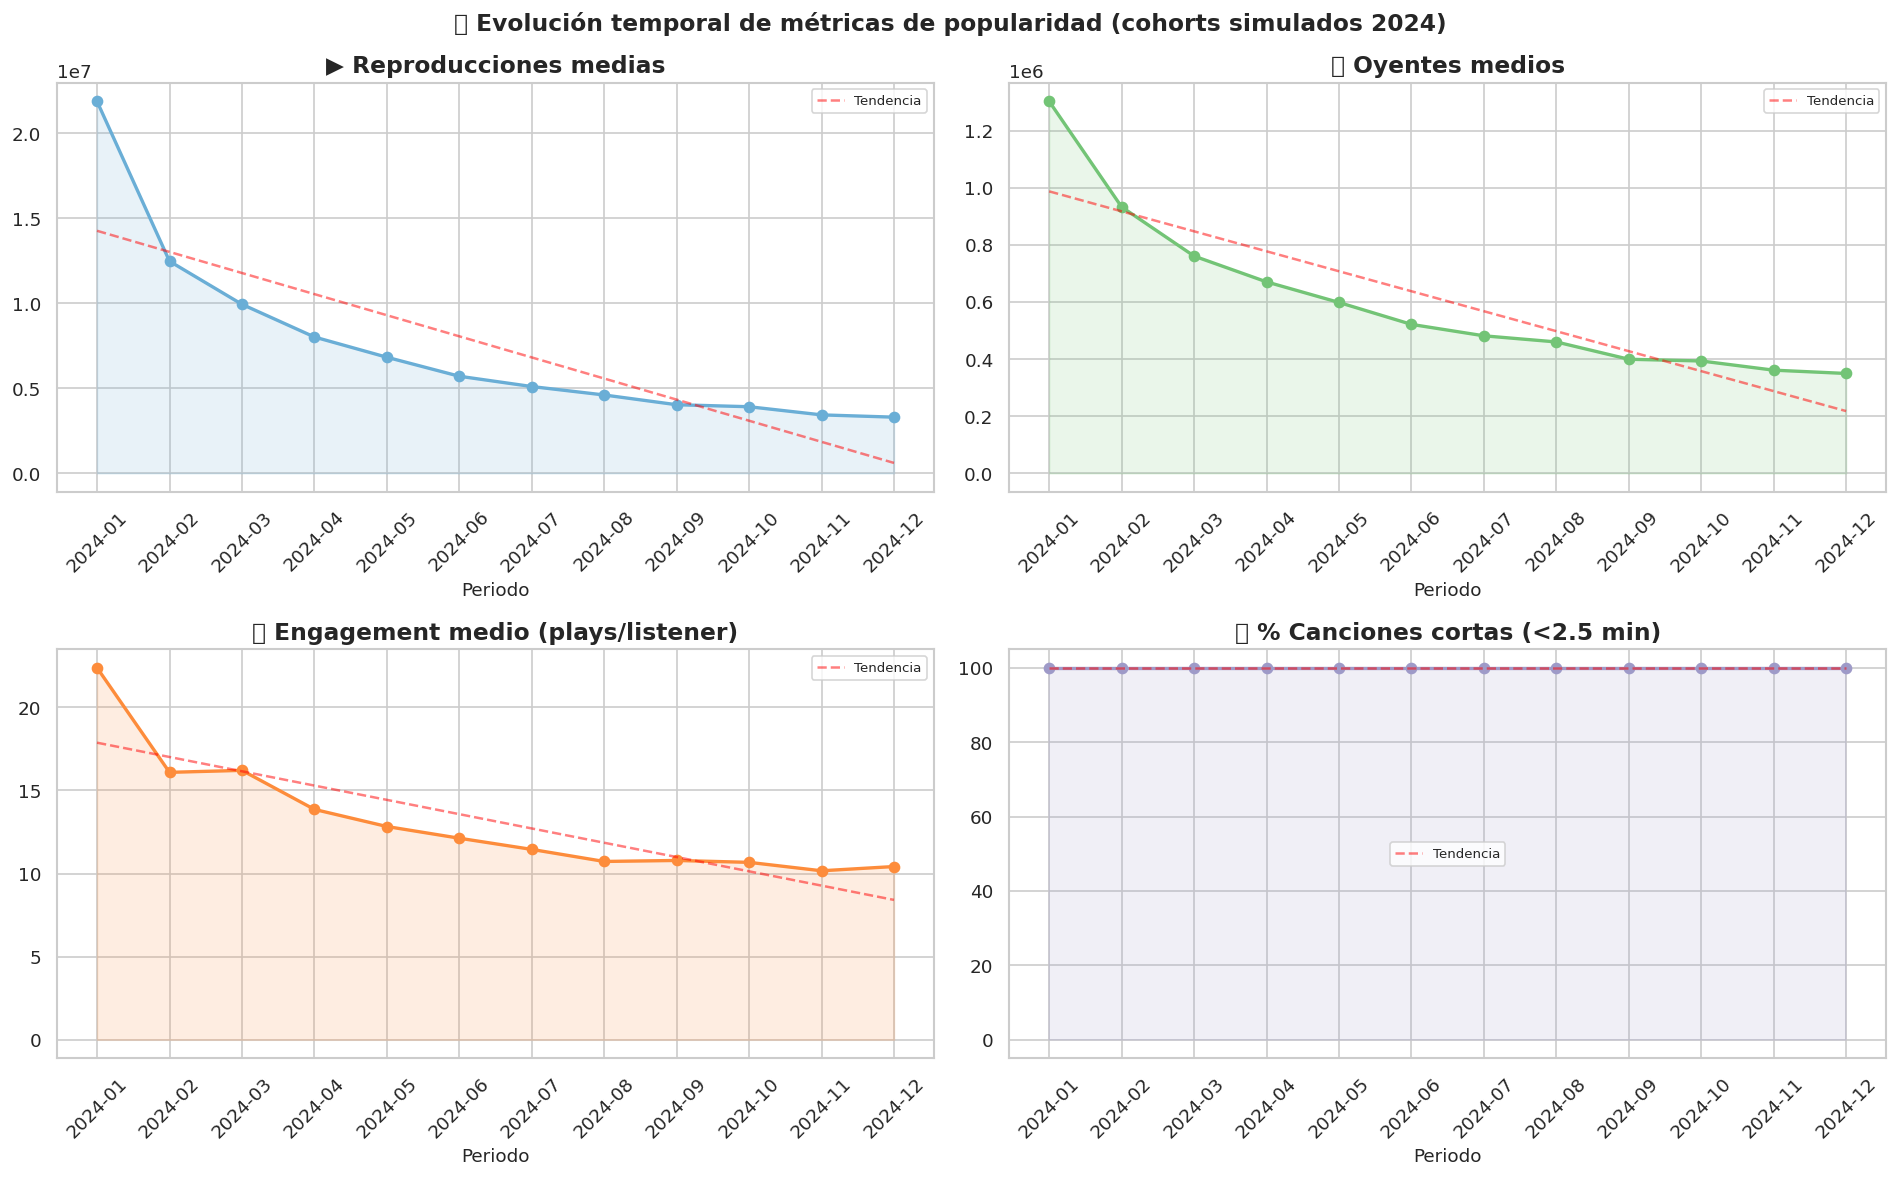


💡 Insights de tendencia:
   Engagement: 📉 decreciente (-11.96 de diferencia inicio→fin del periodo)
   Canciones cortas: 📉 menos predominantes (+0.0pp de cambio)


In [18]:
monthly_stats = (
    df_clean
    .groupby('month_cohort', observed=True)
    .agg(
        avg_playcount=('playcount', 'mean'),
        avg_listeners=('listeners', 'mean'),
        avg_engagement=('playcount_per_listener', 'mean'),
        n_tracks=('name', 'count'),
        short_track_pct=('is_short_track', 'mean')  # % canciones cortas (<2.5 min)
    )
    .reset_index()
)
monthly_stats['short_track_pct'] *= 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics = [
    ('avg_playcount', 'Reproducciones medias', 'Blues', '▶️'),
    ('avg_listeners', 'Oyentes medios', 'Greens', '👥'),
    ('avg_engagement', 'Engagement medio (plays/listener)', 'Oranges', '🔥'),
    ('short_track_pct', '% Canciones cortas (<2.5 min)', 'Purples', '⏱️'),
]

for ax, (col, label, pal, icon) in zip(axes.flatten(), metrics):
    ax.plot(monthly_stats['month_cohort'], monthly_stats[col],
            marker='o', linewidth=2, color=sns.color_palette(pal, 1)[0])
    ax.fill_between(monthly_stats['month_cohort'], monthly_stats[col],
                    alpha=0.15, color=sns.color_palette(pal, 1)[0])
    ax.set_title(f'{icon} {label}')
    ax.set_xlabel('Periodo')
    ax.tick_params(axis='x', rotation=45)
    # Línea de tendencia (regresión lineal simple)
    x_num = range(len(monthly_stats))
    z = np.polyfit(x_num, monthly_stats[col], 1)
    p = np.poly1d(z)
    ax.plot(monthly_stats['month_cohort'], p(x_num),
            linestyle='--', color='red', alpha=0.5, label='Tendencia')
    ax.legend(fontsize=8)

plt.suptitle('📈 Evolución temporal de métricas de popularidad (cohorts simulados 2024)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_temporal_evolution.png', bbox_inches='tight')
plt.show()

# Insights automáticos
engagement_trend = monthly_stats['avg_engagement'].iloc[-1] - monthly_stats['avg_engagement'].iloc[0]
short_track_trend = monthly_stats['short_track_pct'].iloc[-1] - monthly_stats['short_track_pct'].iloc[0]

print(f'\n💡 Insights de tendencia:')
print(f'   Engagement: {"📈 creciente" if engagement_trend > 0 else "📉 decreciente"} '
      f'({engagement_trend:+.2f} de diferencia inicio→fin del periodo)')
print(f'   Canciones cortas: {"📈 más predominantes" if short_track_trend > 0 else "📉 menos predominantes"} '
      f'({short_track_trend:+.1f}pp de cambio)')

### Distribución de playcount (escala normal vs logarítmica)

* Demostrar por qué usamos log-transform para análisis y ML

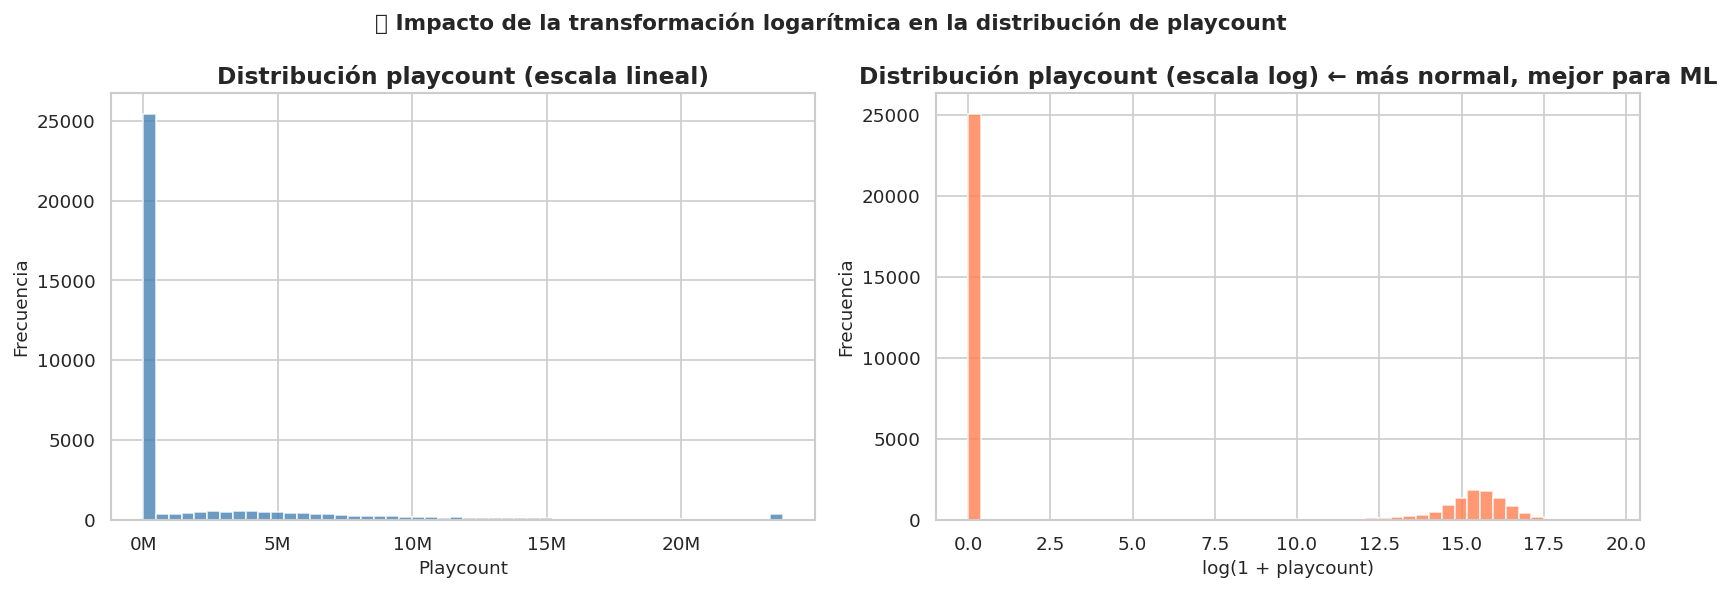

💡 Skewness (sesgo): antes=12.55 → después=0.98
   Una distribución normal tiene skewness ≈ 0. La transformación log lo acerca a 0.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala lineal
axes[0].hist(df_clean['playcount'].clip(upper=df_clean['playcount'].quantile(0.99)),
             bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución playcount (escala lineal)')
axes[0].set_xlabel('Playcount')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Escala logarítmica
axes[1].hist(df_clean['playcount_log'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución playcount (escala log) ← más normal, mejor para ML')
axes[1].set_xlabel('log(1 + playcount)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('📊 Impacto de la transformación logarítmica en la distribución de playcount',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_log_transform.png', bbox_inches='tight')
plt.show()

skew_before = df_clean['playcount'].skew()
skew_after  = df_clean['playcount_log'].skew()
print(f'💡 Skewness (sesgo): antes={skew_before:.2f} → después={skew_after:.2f}')
print(f'   Una distribución normal tiene skewness ≈ 0. La transformación log lo acerca a 0.')

## 3. Géneros: crecimiento vs decrecimiento 

**Objetivo:** identificar qué géneros están dominando el mercado, cuáles están en declive y cuáles son emergentes.

### Vista general de géneros

*  Excluimos UNKNOWN para el análisis de géneros

In [20]:
df_genres = df_clean[df_clean['genre_tag'] != 'UNKNOWN'].copy()

genre_stats = (
    df_genres
    .groupby('genre_tag')
    .agg(
        n_tracks=('name', 'count'),
        total_playcount=('playcount', 'sum'),
        avg_playcount=('playcount', 'mean'),
        avg_listeners=('listeners', 'mean'),
        avg_engagement=('playcount_per_listener', 'mean'),
        pct_short=('is_short_track', 'mean')
    )
    .sort_values('total_playcount', ascending=False)
    .reset_index()
)
genre_stats['pct_short'] *= 100

print(f'📊 Géneros en el dataset: {len(genre_stats)}')
display(genre_stats.head(10))

📊 Géneros en el dataset: 15


,genre_tag,n_tracks,total_playcount,avg_playcount,avg_listeners,avg_engagement,pct_short
0,Hip-Hop,1513,0,0.0,0.0,NaN,100.0
1,alternative,1014,0,0.0,0.0,NaN,100.0
2,ambient,1892,0,0.0,0.0,NaN,100.0
3,classic rock,1774,0,0.0,0.0,NaN,100.0
4,electronic,1062,0,0.0,0.0,NaN,100.0
5,experimental,1650,0,0.0,0.0,NaN,100.0
6,female vocalists,1112,0,0.0,0.0,NaN,100.0
7,folk,1164,0,0.0,0.0,NaN,100.0
8,instrumental,1749,0,0.0,0.0,NaN,100.0
9,jazz,1933,0,0.0,0.0,NaN,100.0


### Comparativa visual entre géneros

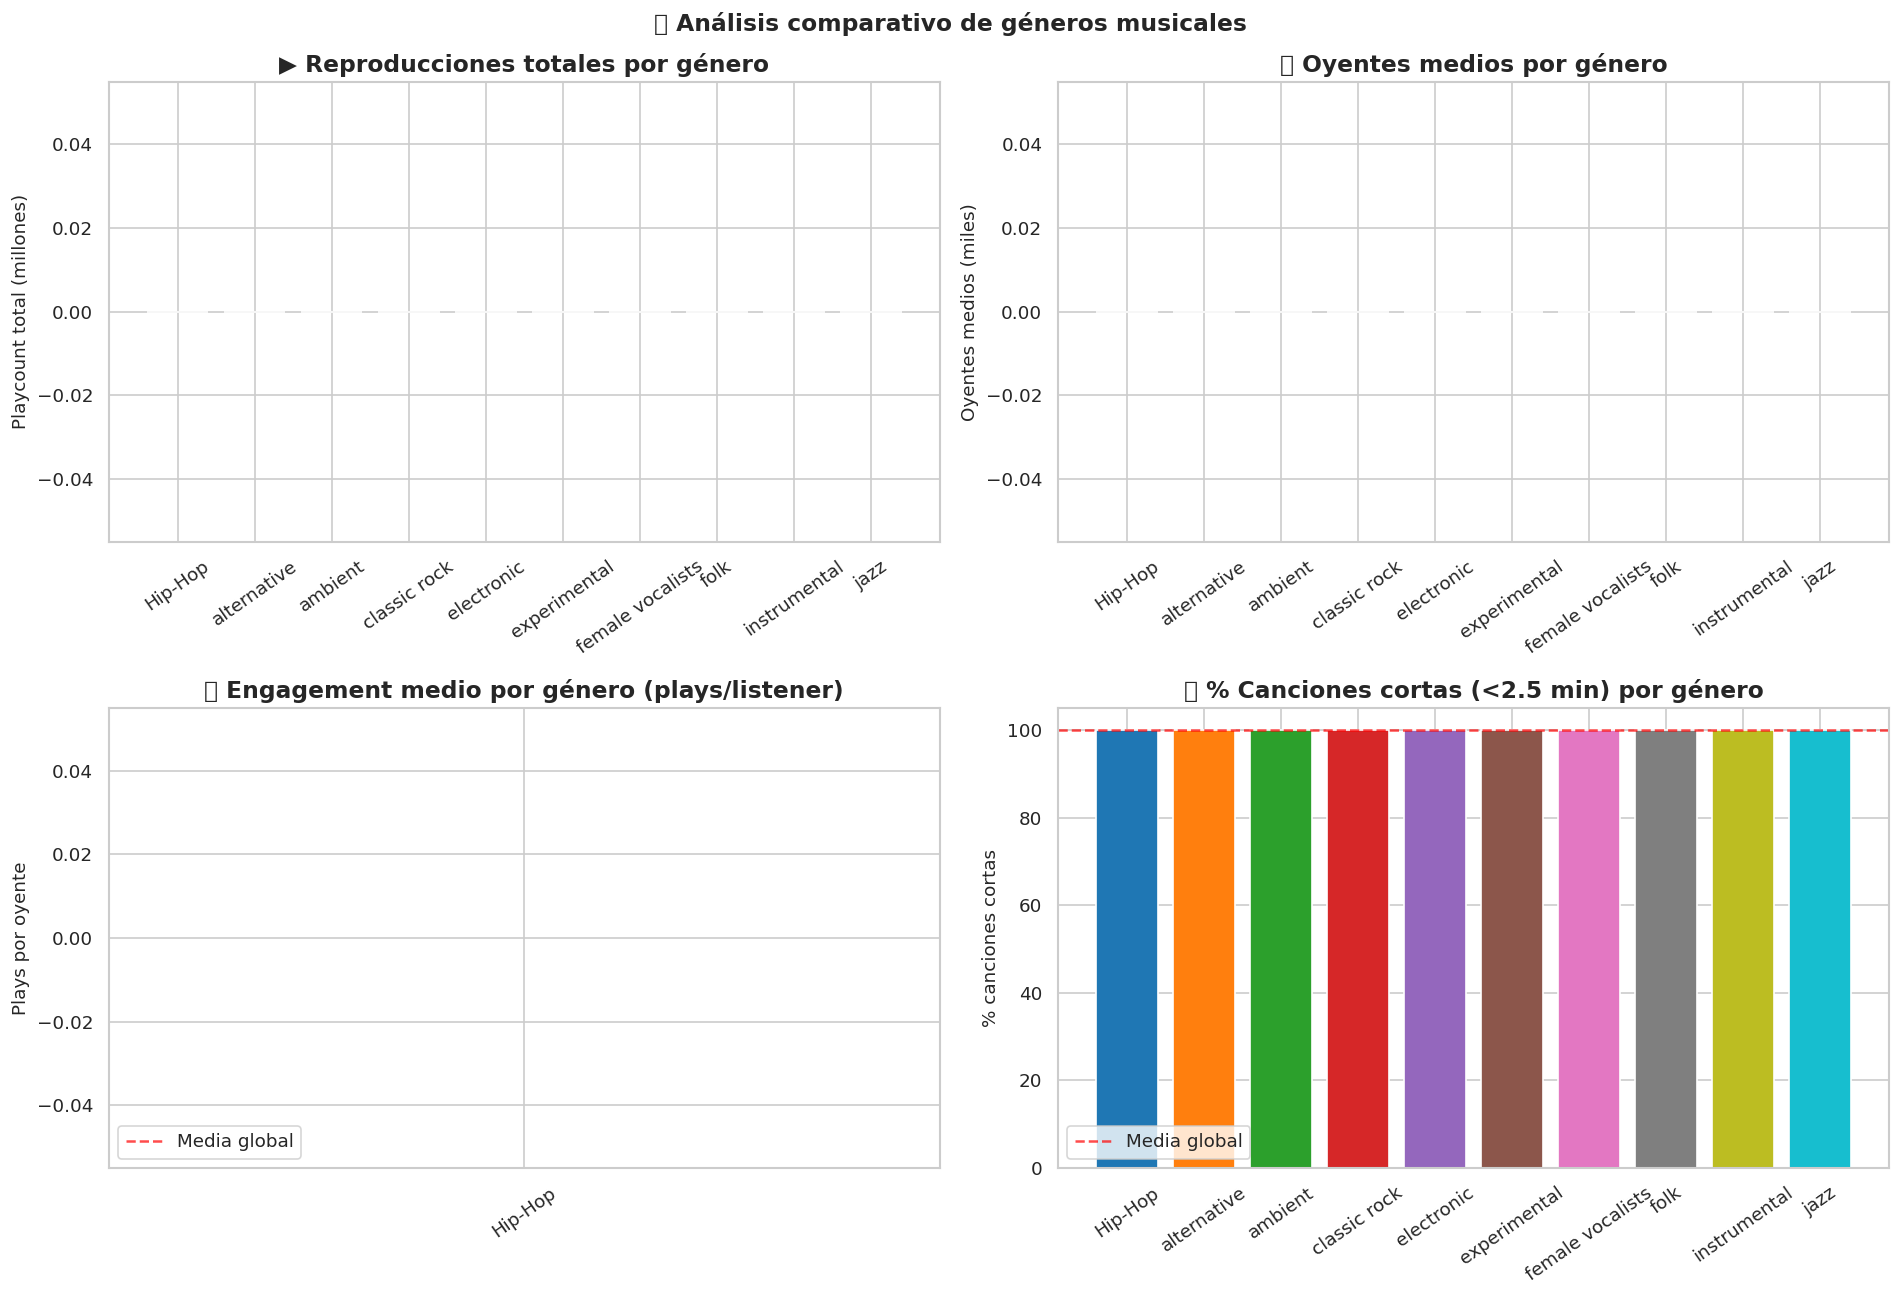

In [21]:

top_genres = genre_stats.head(10)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

palette = sns.color_palette('tab10', 10)

# Reproducciones totales
axes[0, 0].bar(top_genres['genre_tag'], top_genres['total_playcount'] / 1e6, color=palette)
axes[0, 0].set_title('▶️ Reproducciones totales por género')
axes[0, 0].set_ylabel('Playcount total (millones)')
axes[0, 0].tick_params(axis='x', rotation=35)

# Oyentes medios
axes[0, 1].bar(top_genres['genre_tag'], top_genres['avg_listeners'] / 1e3, color=palette)
axes[0, 1].set_title('👤 Oyentes medios por género')
axes[0, 1].set_ylabel('Oyentes medios (miles)')
axes[0, 1].tick_params(axis='x', rotation=35)

# Engagement
axes[1, 0].bar(top_genres['genre_tag'], top_genres['avg_engagement'], color=palette)
axes[1, 0].set_title('🔥 Engagement medio por género (plays/listener)')
axes[1, 0].set_ylabel('Plays por oyente')
axes[1, 0].tick_params(axis='x', rotation=35)
axes[1, 0].axhline(genre_stats['avg_engagement'].mean(), color='red',
                   linestyle='--', alpha=0.7, label='Media global')
axes[1, 0].legend()

# % Canciones cortas
axes[1, 1].bar(top_genres['genre_tag'], top_genres['pct_short'], color=palette)
axes[1, 1].set_title('⏱️ % Canciones cortas (<2.5 min) por género')
axes[1, 1].set_ylabel('% canciones cortas')
axes[1, 1].tick_params(axis='x', rotation=35)
axes[1, 1].axhline(df_clean['is_short_track'].mean() * 100, color='red',
                   linestyle='--', alpha=0.7, label='Media global')
axes[1, 1].legend()

plt.suptitle('🎵 Análisis comparativo de géneros musicales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_genre_comparison.png', bbox_inches='tight')
plt.show()

### Géneros en crecimiento vs declive


* Comparamos la presencia de cada género en la primera mitad del ranking
* vs la segunda mitad. Si un género tiene más tracks en el top 50%,
* es emergente. Si los tiene en el fondo, está en declive.

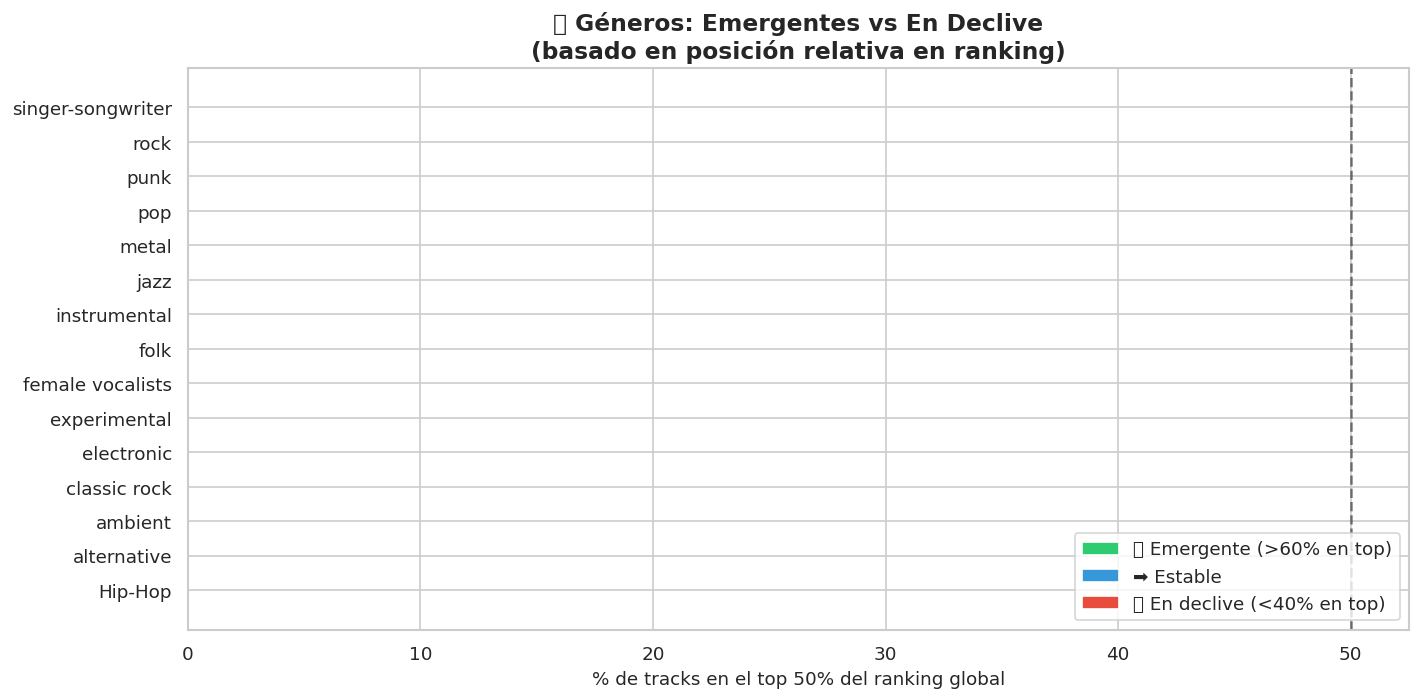


💡 Géneros EMERGENTES: []
💡 Géneros en DECLIVE: ['Hip-Hop', 'alternative', 'ambient', 'classic rock', 'electronic', 'experimental', 'female vocalists', 'folk', 'instrumental', 'jazz', 'metal', 'pop', 'punk', 'rock', 'singer-songwriter']

🎯 Recomendación de negocio:
   → Revisar estrategia en géneros en declive: Hip-Hop, alternative, ambient


In [22]:
median_rank = df_clean['rank_global'].median()

genre_growth = (
    df_genres
    .assign(is_trending=lambda x: (x['rank_global'] <= median_rank).astype(int))
    .groupby('genre_tag')
    .agg(
        pct_trending=('is_trending', 'mean'),
        avg_playcount=('playcount', 'mean'),
        n_tracks=('name', 'count')
    )
    .query('n_tracks >= 5')  # solo géneros con suficiente masa
    .sort_values('pct_trending', ascending=False)
    .reset_index()
)
genre_growth['pct_trending'] *= 100
# Clasificación
genre_growth['status'] = genre_growth['pct_trending'].apply(
    lambda x: '🚀 Emergente' if x > 60 else ('📉 En declive' if x < 40 else '➡️ Estable')
)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
colors = genre_growth['status'].map({'🚀 Emergente': '#2ecc71', '➡️ Estable': '#3498db', '📉 En declive': '#e74c3c'})
ax.barh(genre_growth['genre_tag'], genre_growth['pct_trending'], color=colors)
ax.axvline(50, color='black', linestyle='--', alpha=0.5, label='50% — línea de equilibrio')
ax.set_xlabel('% de tracks en el top 50% del ranking global')
ax.set_title('📊 Géneros: Emergentes vs En Declive\n(basado en posición relativa en ranking)')
ax.legend()

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='🚀 Emergente (>60% en top)'),
                   Patch(facecolor='#3498db', label='➡️ Estable'),
                   Patch(facecolor='#e74c3c', label='📉 En declive (<40% en top)')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('plot_genre_growth.png', bbox_inches='tight')
plt.show()

# Insights
emergentes = genre_growth[genre_growth['status'] == '🚀 Emergente']['genre_tag'].tolist()
declive    = genre_growth[genre_growth['status'] == '📉 En declive']['genre_tag'].tolist()
print(f'\n💡 Géneros EMERGENTES: {emergentes}')
print(f'💡 Géneros en DECLIVE: {declive}')
print(f'\n🎯 Recomendación de negocio:')
if emergentes:
    print(f'   → Priorizar producción en géneros emergentes: {", ".join(emergentes[:3])}')
if declive:
    print(f'   → Revisar estrategia en géneros en declive: {", ".join(declive[:3])}')

### Evolución de géneros por periodo

* Top 5 géneros y su evolución mensual (basado en playcount medio)

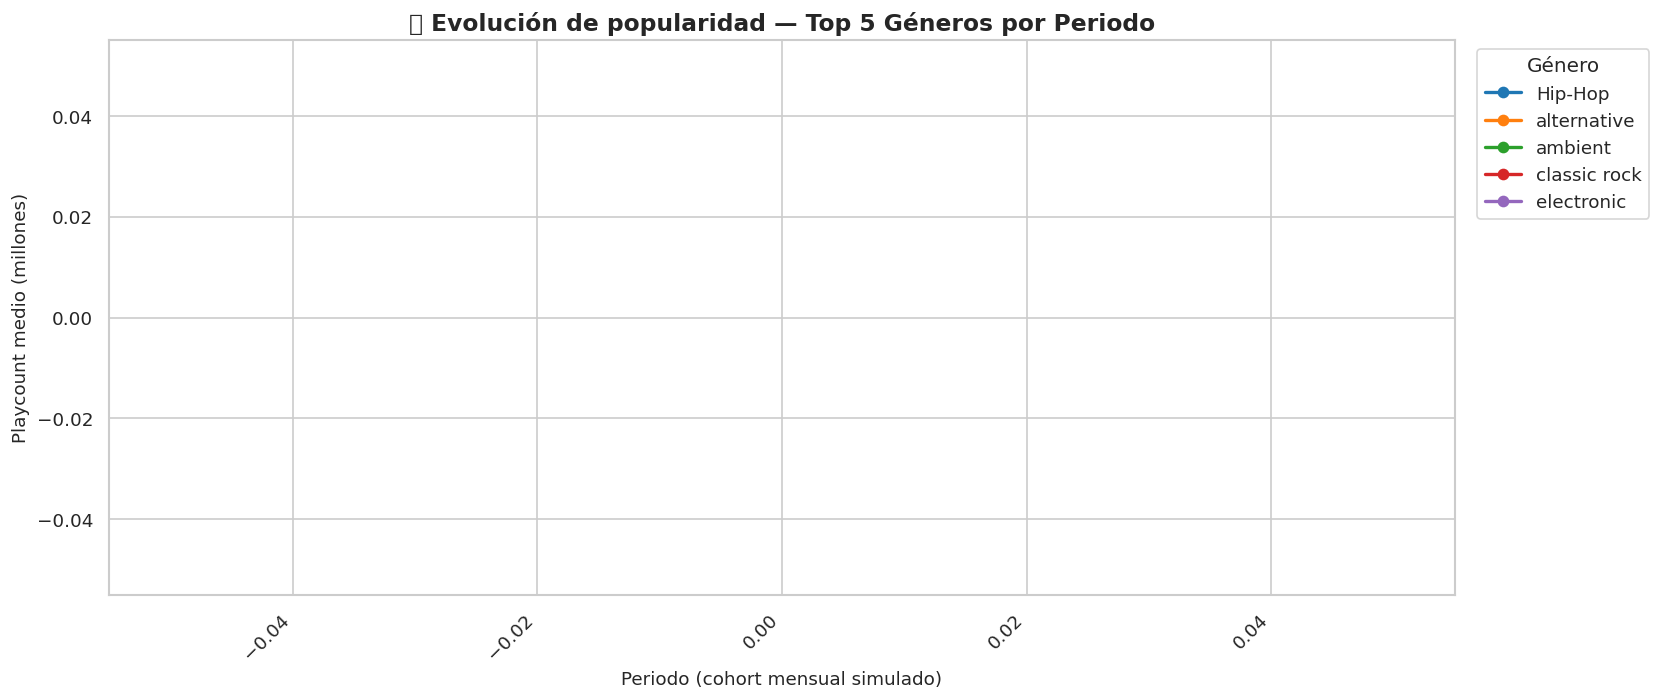

In [23]:

top5_genres = genre_stats.head(5)['genre_tag'].tolist()

genre_monthly = (
    df_genres[df_genres['genre_tag'].isin(top5_genres)]
    .groupby(['month_cohort', 'genre_tag'], observed=True)['playcount']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

for genre, color in zip(top5_genres, sns.color_palette('tab10', 5)):
    data = genre_monthly[genre_monthly['genre_tag'] == genre]
    ax.plot(data['month_cohort'], data['playcount'] / 1e6,
            marker='o', label=genre, linewidth=2, color=color)

ax.set_xlabel('Periodo (cohort mensual simulado)')
ax.set_ylabel('Playcount medio (millones)')
ax.set_title('📈 Evolución de popularidad — Top 5 Géneros por Periodo')
ax.legend(title='Género', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_genre_evolution.png', bbox_inches='tight')
plt.show()

## 4. Análisis geográfico

**Objetivo:** Identificar los países con mayor consumo y detectar si hay diferencias culturales en las preferencias musicales.

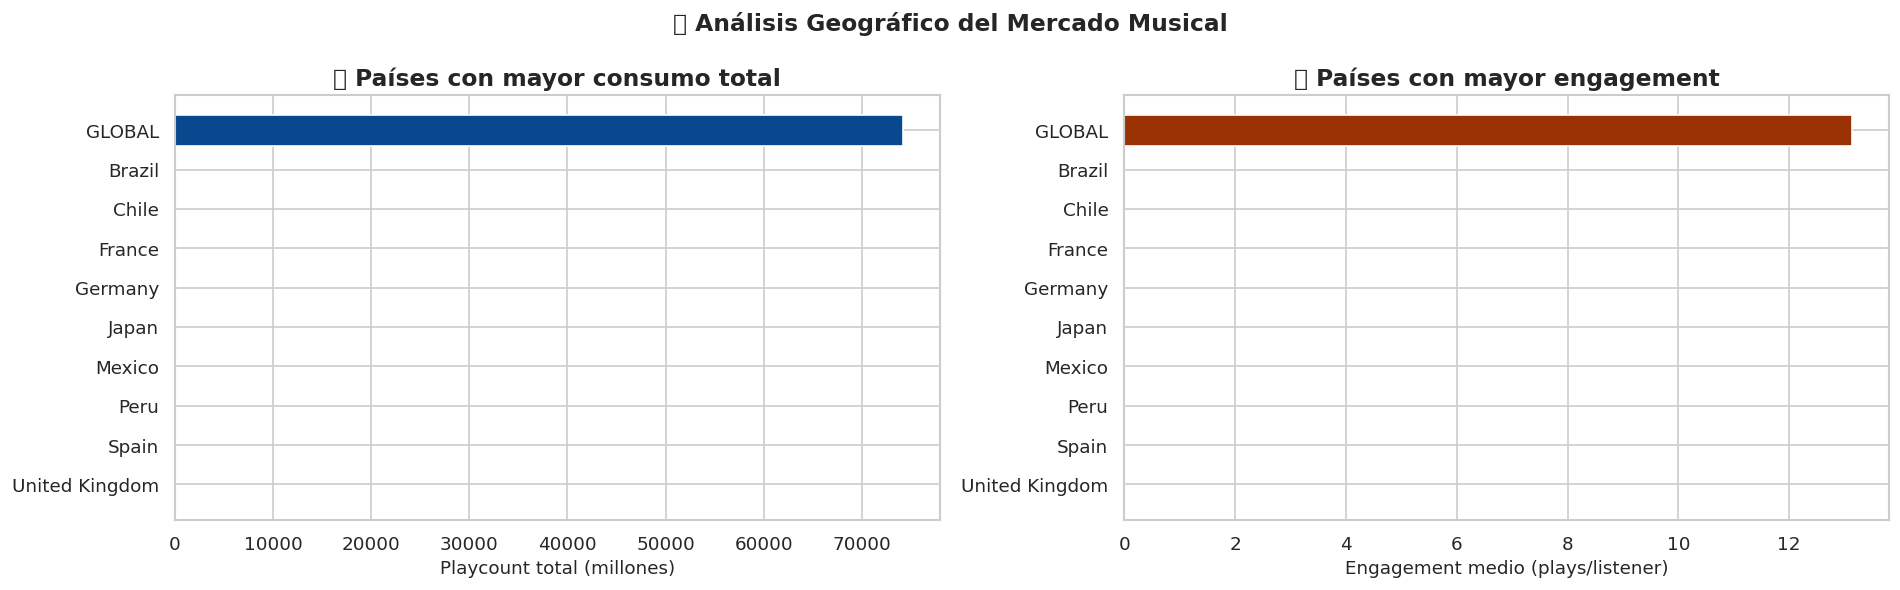


💡 País con mayor consumo: GLOBAL (74224.3M plays, 9,982 tracks en el dataset)


In [24]:
df_geo = df_clean[df_clean['country'] != 'UNKNOWN'].copy()

country_stats = (
    df_geo
    .groupby('country')
    .agg(
        n_tracks=('name', 'count'),
        total_playcount=('playcount', 'sum'),
        avg_playcount=('playcount', 'mean'),
        avg_engagement=('playcount_per_listener', 'mean'),
        pct_short=('is_short_track', 'mean')
    )
    .sort_values('total_playcount', ascending=False)
    .reset_index()
)
country_stats['pct_short'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Playcount total
axes[0].barh(country_stats['country'], country_stats['total_playcount'] / 1e6,
             color=sns.color_palette('Blues_r', len(country_stats)))
axes[0].invert_yaxis()
axes[0].set_xlabel('Playcount total (millones)')
axes[0].set_title('🌍 Países con mayor consumo total')

# Engagement
axes[1].barh(country_stats.sort_values('avg_engagement', ascending=False)['country'],
             country_stats.sort_values('avg_engagement', ascending=False)['avg_engagement'],
             color=sns.color_palette('Oranges_r', len(country_stats)))
axes[1].invert_yaxis()
axes[1].set_xlabel('Engagement medio (plays/listener)')
axes[1].set_title('🔥 Países con mayor engagement')

plt.suptitle('📊 Análisis Geográfico del Mercado Musical', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_geo_analysis.png', bbox_inches='tight')
plt.show()

top_country = country_stats.iloc[0]
print(f'\n💡 País con mayor consumo: {top_country["country"]} '
      f'({top_country["total_playcount"]/1e6:.1f}M plays, '
      f'{top_country["n_tracks"]:,} tracks en el dataset)')

### Heatmap de géneros por país

* ¿Qué géneros dominan en cada país? 

In [25]:
df_geo_genre = df_clean[
    (df_clean['country'] != 'UNKNOWN') & (df_clean['genre_tag'] != 'UNKNOWN')
].copy()

if len(df_geo_genre) > 0:
    genre_country_pivot = (
        df_geo_genre
        .groupby(['country', 'genre_tag'])['playcount']
        .sum()
        .unstack(fill_value=0)
    )
    # Normalizar por fila (para ver preferencia relativa, no volumen absoluto)
    genre_country_norm = genre_country_pivot.div(genre_country_pivot.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(genre_country_norm, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': '% del consumo del país'})
    ax.set_title('🌍 Distribución de géneros por país (% del consumo total)', fontweight='bold')
    ax.set_xlabel('Género')
    ax.set_ylabel('País')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig('plot_genre_country_heatmap.png', bbox_inches='tight')
    plt.show()
else:
    print('⚠️  No hay suficientes datos geo+genre para el heatmap.')
    print('   Este análisis estará disponible cuando los endpoints geo y tag estén cruzados.')

⚠️  No hay suficientes datos geo+genre para el heatmap.
   Este análisis estará disponible cuando los endpoints geo y tag estén cruzados.


## 5. Correlaciones

+ **Objetivo:** Entender qué variables están correlacionadas entre sí y con la popularidad. Esto guía el feature selection para los modelos ML.

### Heatmap de correlaciones

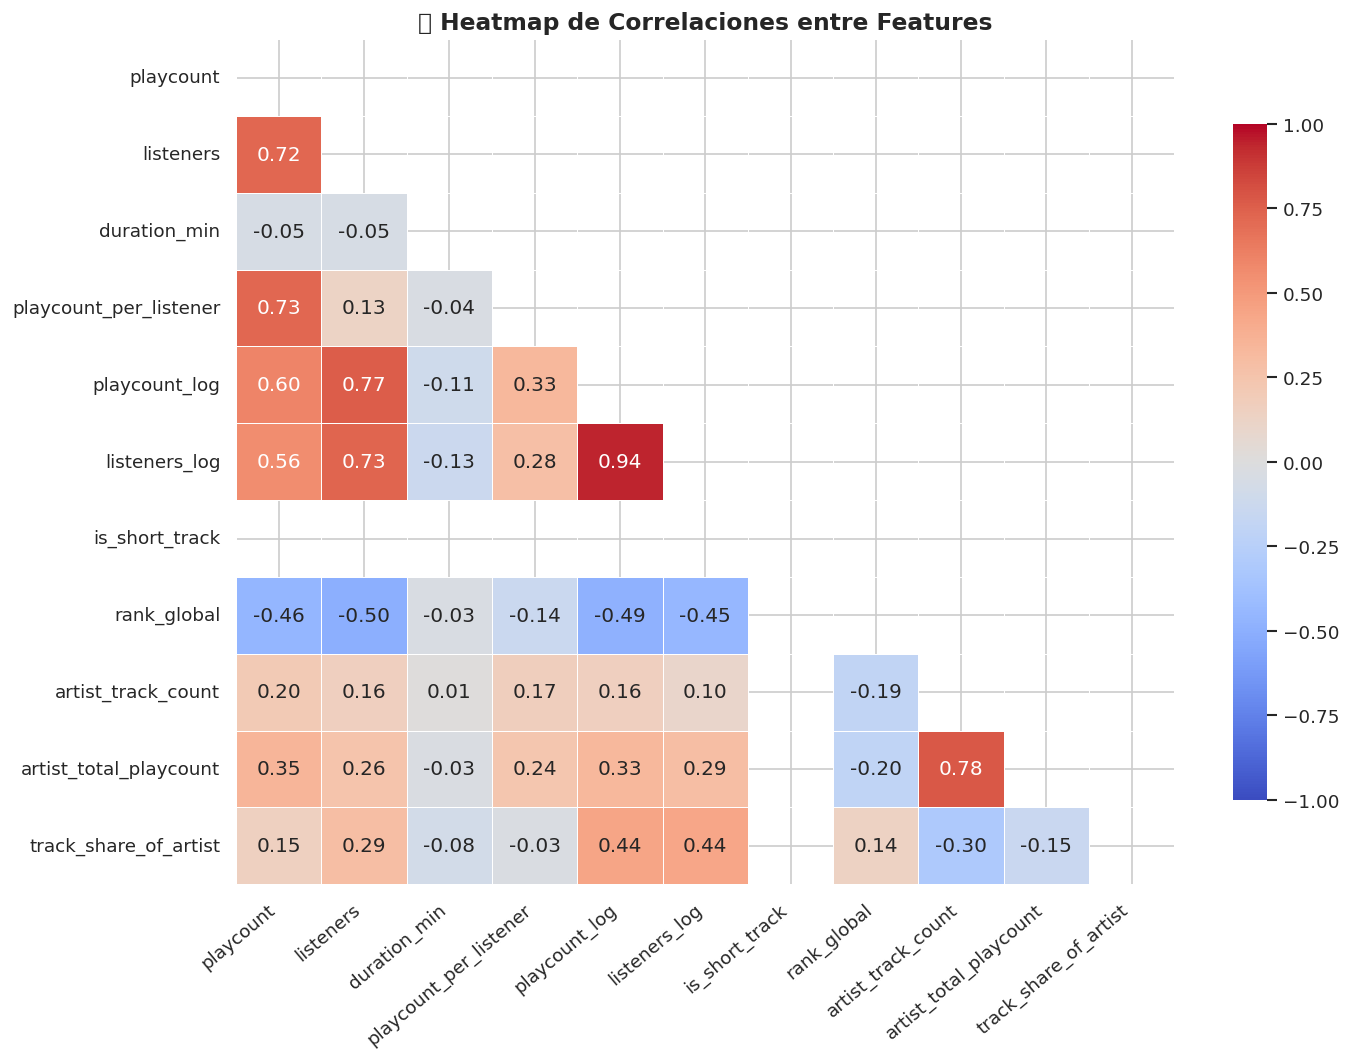


💡 Variables más correlacionadas con playcount (popularidad):
   + playcount_per_listener: r=0.726
   + listeners: r=0.721
   + playcount_log: r=0.600
   + listeners_log: r=0.557
   - rank_global: r=-0.461


In [26]:
numeric_cols = [
    'playcount', 'listeners', 'duration_min',
    'playcount_per_listener', 'playcount_log', 'listeners_log',
    'is_short_track', 'rank_global', 'artist_track_count',
    'artist_total_playcount', 'track_share_of_artist'
]
# Nos quedamos con las que existen en df_clean
numeric_cols = [c for c in numeric_cols if c in df_clean.columns]

corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # ocultamos triángulo superior
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('🔗 Heatmap de Correlaciones entre Features', fontweight='bold', fontsize=14)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Insights: correlaciones más altas con playcount
corr_with_playcount = corr_matrix['playcount'].drop('playcount').abs().sort_values(ascending=False)
print('\n💡 Variables más correlacionadas con playcount (popularidad):')
for feat, val in corr_with_playcount.head(5).items():
    direction = '+' if corr_matrix['playcount'][feat] > 0 else '-'
    print(f'   {direction} {feat}: r={corr_matrix["playcount"][feat]:.3f}')

### Scatter plots de relaciones clave

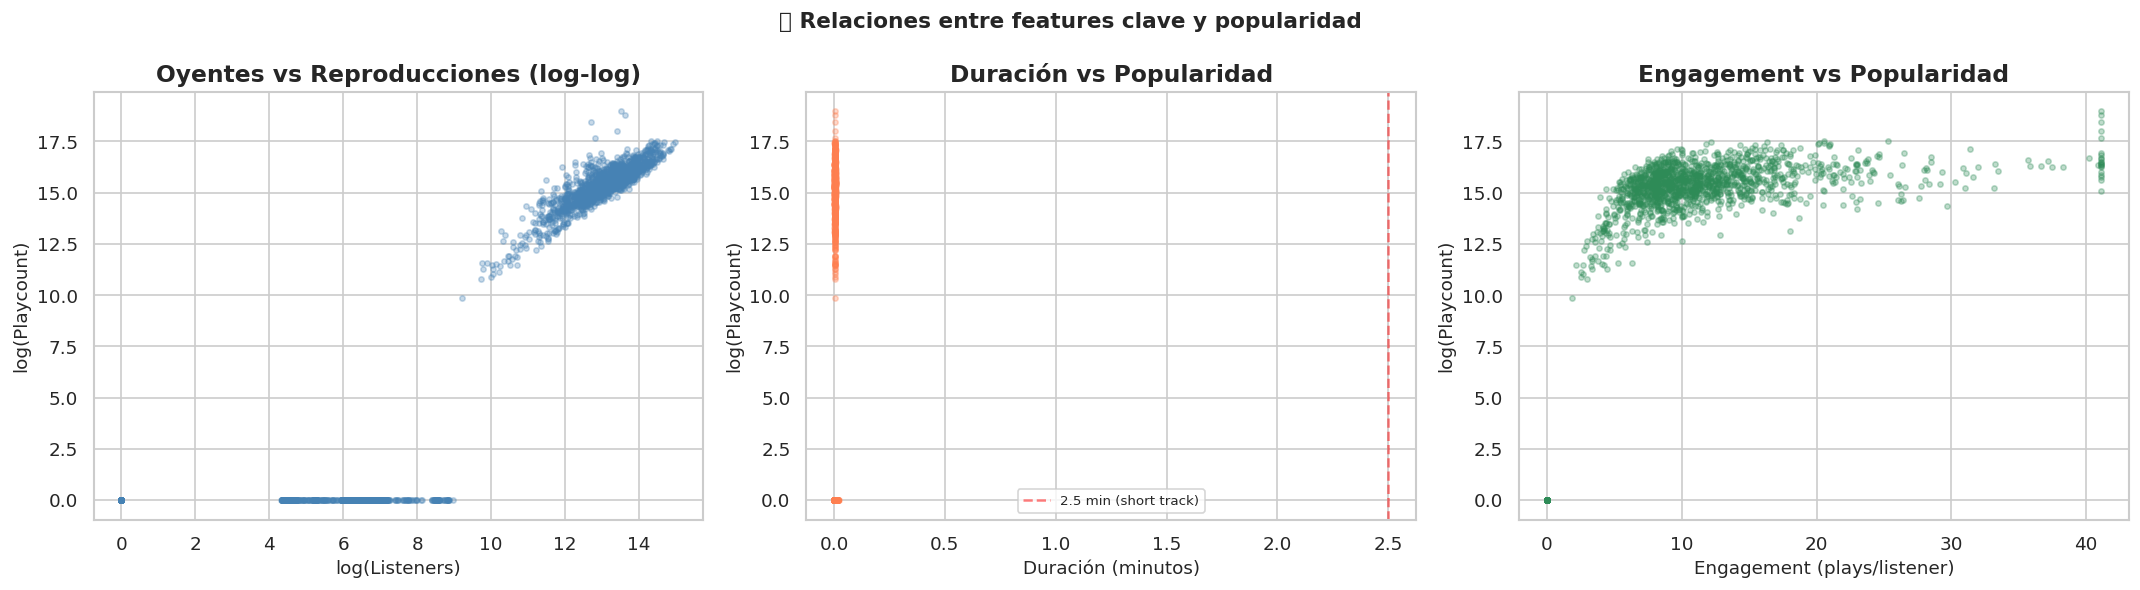

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sample para no sobrecargar el plot
df_sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)

# Listeners vs Playcount (en log)
axes[0].scatter(df_sample['listeners_log'], df_sample['playcount_log'],
                alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('log(Listeners)')
axes[0].set_ylabel('log(Playcount)')
axes[0].set_title('Oyentes vs Reproducciones (log-log)')

# Duración vs Playcount (log)
axes[1].scatter(df_sample['duration_min'], df_sample['playcount_log'],
                alpha=0.3, s=10, color='coral')
axes[1].set_xlabel('Duración (minutos)')
axes[1].set_ylabel('log(Playcount)')
axes[1].set_title('Duración vs Popularidad')
axes[1].axvline(2.5, color='red', linestyle='--', alpha=0.5, label='2.5 min (short track)')
axes[1].legend(fontsize=8)

# Engagement vs Playcount (log)
axes[2].scatter(df_sample['playcount_per_listener'].clip(upper=df_sample['playcount_per_listener'].quantile(0.99)),
                df_sample['playcount_log'],
                alpha=0.3, s=10, color='seagreen')
axes[2].set_xlabel('Engagement (plays/listener)')
axes[2].set_ylabel('log(Playcount)')
axes[2].set_title('Engagement vs Popularidad')

plt.suptitle('🔍 Relaciones entre features clave y popularidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_scatter_features.png', bbox_inches='tight')
plt.show()

### Análisis de duración — ¿las canciones cortas son más populares? 

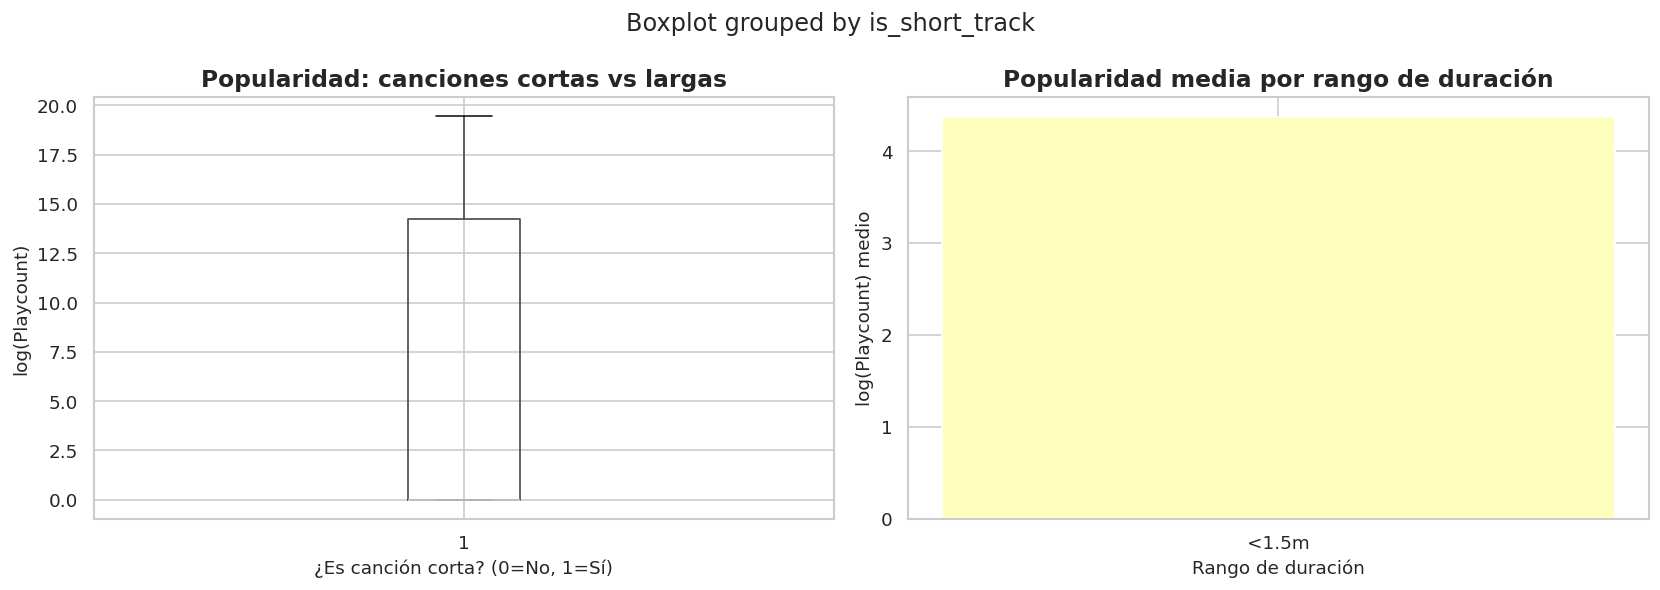


💡 Insight de duración:
   Canciones cortas (<2.5 min) — log(playcount) medio: 4.372
   Canciones largas (≥2.5 min) — log(playcount) medio: nan
   → Las canciones largas son más populares en este dataset.
   → 100.0% de los tracks son canciones cortas (<2.5 min).


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: playcount por is_short_track
df_clean.boxplot(column='playcount_log', by='is_short_track', ax=axes[0])
axes[0].set_title('Popularidad: canciones cortas vs largas')
axes[0].set_xlabel('¿Es canción corta? (0=No, 1=Sí)')
axes[0].set_ylabel('log(Playcount)')
plt.sca(axes[0])
plt.title('Popularidad: canciones cortas vs largas')

# Duración vs popularidad por rango de duración
df_clean['duration_bucket'] = pd.cut(df_clean['duration_min'],
                                      bins=[0, 1.5, 2.5, 3.5, 4.5, 6, 100],
                                      labels=['<1.5m', '1.5-2.5m', '2.5-3.5m', '3.5-4.5m', '4.5-6m', '>6m'])
duration_pop = df_clean.groupby('duration_bucket', observed=True)['playcount_log'].mean().reset_index()

axes[1].bar(duration_pop['duration_bucket'], duration_pop['playcount_log'],
            color=sns.color_palette('RdYlGn', len(duration_pop)))
axes[1].set_xlabel('Rango de duración')
axes[1].set_ylabel('log(Playcount) medio')
axes[1].set_title('Popularidad media por rango de duración')

plt.tight_layout()
plt.savefig('plot_duration_popularity.png', bbox_inches='tight')
plt.show()

# Insight
short_mean = df_clean[df_clean['is_short_track'] == 1]['playcount_log'].mean()
long_mean  = df_clean[df_clean['is_short_track'] == 0]['playcount_log'].mean()
winner = 'cortas' if short_mean > long_mean else 'largas'
print(f'\n💡 Insight de duración:')
print(f'   Canciones cortas (<2.5 min) — log(playcount) medio: {short_mean:.3f}')
print(f'   Canciones largas (≥2.5 min) — log(playcount) medio: {long_mean:.3f}')
print(f'   → Las canciones {winner} son más populares en este dataset.')
pct_short = df_clean['is_short_track'].mean() * 100
print(f'   → {pct_short:.1f}% de los tracks son canciones cortas (<2.5 min).')

# **ML**

## **Definición del problema:** 



* Regresión → predecir popularidad (0–100)

* Clasificación → hit vs no hit

2. **Modelos básicos (mínimo viable):** (1) Linear Regression; (2) Random Forest; (3) XGBoost / LightGBM

3. **Evaluación:** (1) RMSE / MAE (regresión); (2) Accuracy / F1 (clasificación)

4. **Interpretabilidad:**

* Feature importance

* SHAP values (muy top para destacar)

**Objetivo:** Predecir si una canción va a ser un hit.  

**Definición del problema:**  
- **Regresión** → predecir `playcount_log` (popularidad continua)  
- **Clasificación** → predecir `is_hit` (hit vs no hit, umbral = percentil 75 de playcount)  

**Modelos:** Linear Regression (baseline) → Random Forest → XGBoost

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier, XGBRegressor
    XGBOOST_AVAILABLE = True
    print('✅ XGBoost disponible')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('⚠️  XGBoost no disponible. Instala con: pip install xgboost')

print('✅ Librerías ML importadas')

✅ XGBoost disponible
✅ Librerías ML importadas


## 1. Preparación del dataset para ML 



* Target 1 — Regresión: predecir log de reproducciones
* Target 2 — Clasificación: hit (>= percentil 75) vs no hit

In [30]:
hit_threshold = df_clean['playcount'].quantile(0.75)
df_clean['is_hit'] = (df_clean['playcount'] >= hit_threshold).astype(int)

print(f'🎯 Umbral de "hit": {hit_threshold:,.0f} reproducciones (percentil 75)')
print(f'   Hits en el dataset: {df_clean["is_hit"].sum():,} ({df_clean["is_hit"].mean()*100:.1f}%)')
print(f'   No hits: {(1-df_clean["is_hit"]).sum():,} ({(1-df_clean["is_hit"].mean())*100:.1f}%)')

# ── Features para ML ─────────────────────────────────────────────────────────
# Encodear variables categóricas
df_ml = df_clean.copy()

le_genre   = LabelEncoder()
le_country = LabelEncoder()

df_ml['genre_encoded']   = le_genre.fit_transform(df_ml['genre_tag'].fillna('UNKNOWN'))
df_ml['country_encoded'] = le_country.fit_transform(df_ml['country'].fillna('UNKNOWN'))

FEATURE_COLS = [
    'listeners_log',          # popularidad de oyentes (proxy de demanda)
    'duration_min',           # duración de la canción
    'is_short_track',         # flag formato corto (TikTok)
    'genre_encoded',          # género musical
    'country_encoded',        # país de origen del dato
    'artist_track_count',     # cuántos tracks tiene el artista en el dataset
    'track_share_of_artist',  # peso de la canción en el catálogo del artista
    'playcount_per_listener', # engagement
]
FEATURE_COLS = [f for f in FEATURE_COLS if f in df_ml.columns]

df_ml_clean = df_ml[FEATURE_COLS + ['playcount_log', 'is_hit']].dropna()
print(f'\nDataset ML: {len(df_ml_clean):,} filas | {len(FEATURE_COLS)} features')

🎯 Umbral de "hit": 1,554,757 reproducciones (percentil 75)
   Hits en el dataset: 8,764 (25.0%)
   No hits: 26,292 (75.0%)

Dataset ML: 10,781 filas | 8 features


## 2. Train / Test split

In [31]:
X = df_ml_clean[FEATURE_COLS]
y_reg  = df_ml_clean['playcount_log']   # para regresión
y_clf  = df_ml_clean['is_hit']          # para clasificación

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42  # mismo split
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Split: {len(X_train):,} train | {len(X_test):,} test')

✅ Split: 8,624 train | 2,157 test


## 3. REGRESIÓN — Predecir popularidad (playcount_log)

In [32]:
results_reg = {}


* Baseline: Linear Regression

In [33]:
lr = LinearRegression()
lr.fit(X_train_sc, y_reg_train)
y_pred_lr = lr.predict(X_test_sc)
results_reg['Linear Regression'] = {
    'RMSE': np.sqrt(mean_squared_error(y_reg_test, y_pred_lr)),
    'MAE' : mean_absolute_error(y_reg_test, y_pred_lr),
    'R²'  : r2_score(y_reg_test, y_pred_lr)
}


* Random Forest Regressor

In [34]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)
y_pred_rf = rf_reg.predict(X_test)
results_reg['Random Forest'] = {
    'RMSE': np.sqrt(mean_squared_error(y_reg_test, y_pred_rf)),
    'MAE' : mean_absolute_error(y_reg_test, y_pred_rf),
    'R²'  : r2_score(y_reg_test, y_pred_rf)
}



* XGBoost (si disponible)

In [35]:
if XGBOOST_AVAILABLE:
    xgb_reg = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb_reg.fit(X_train, y_reg_train)
    y_pred_xgb = xgb_reg.predict(X_test)
    results_reg['XGBoost'] = {
        'RMSE': np.sqrt(mean_squared_error(y_reg_test, y_pred_xgb)),
        'MAE' : mean_absolute_error(y_reg_test, y_pred_xgb),
        'R²'  : r2_score(y_reg_test, y_pred_xgb)
    }


In [36]:

df_results_reg = pd.DataFrame(results_reg).T
print('📊 Resultados de REGRESIÓN (predecir log de reproducciones):')
display(df_results_reg.style.highlight_min(subset=['RMSE', 'MAE'], color='lightgreen')
                            .highlight_max(subset=['R²'], color='lightgreen')
                            .format('{:.4f}'))

best_model = df_results_reg['R²'].idxmax()
print(f'\n🏆 Mejor modelo: {best_model} (R²={df_results_reg.loc[best_model, "R²"]:.4f})')

📊 Resultados de REGRESIÓN (predecir log de reproducciones):


,RMSE,MAE,R²
Linear Regression,1.2878,0.8575,0.9032
Random Forest,0.0756,0.0153,0.9997
XGBoost,0.0664,0.0260,0.9997



🏆 Mejor modelo: XGBoost (R²=0.9997)


## 4. CLASIFICACIÓN — Predecir hit vs no hit

In [37]:
results_clf = {}

models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBOOST_AVAILABLE:
    models_clf['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, verbosity=0, eval_metric='logloss')

for name, model in models_clf.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_clf_train)
    y_pred = model.predict(X_te)
    results_clf[name] = {
        'Accuracy' : (y_pred == y_clf_test).mean(),
        'F1 (hit)' : __import__('sklearn.metrics', fromlist=['f1_score']).f1_score(y_clf_test, y_pred, pos_label=1),
    }

df_results_clf = pd.DataFrame(results_clf).T
print('📊 Resultados de CLASIFICACIÓN (predecir hit vs no hit):')
display(df_results_clf.style.highlight_max(color='lightgreen').format('{:.4f}'))

best_clf = df_results_clf['F1 (hit)'].idxmax()
print(f'\n🏆 Mejor clasificador: {best_clf} (F1={df_results_clf.loc[best_clf, "F1 (hit)"]:.4f})')

📊 Resultados de CLASIFICACIÓN (predecir hit vs no hit):


,Accuracy,F1 (hit)
Logistic Regression,0.9940,0.9964
Random Forest,0.9977,0.9986
XGBoost,0.9972,0.9983



🏆 Mejor clasificador: Random Forest (F1=0.9986)


### Feature Importance — ¿qué variables predicen un hit? 


* Usamos el Random Forest (interpretable y robusto)

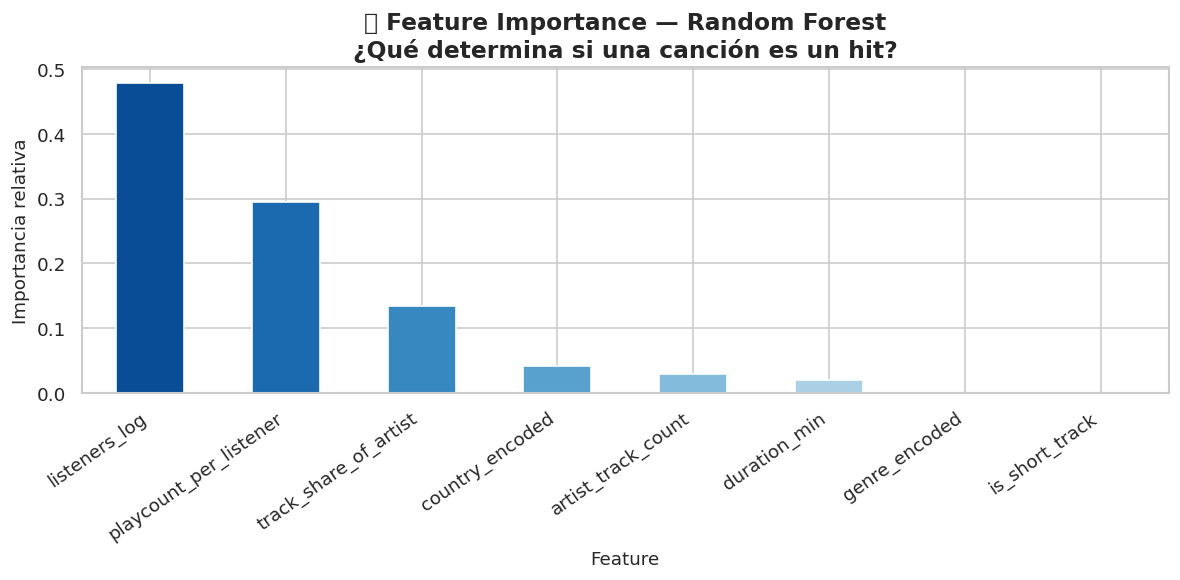


💡 Las 3 variables más importantes para predecir un hit:
   1. listeners_log (47.9% de importancia)
   2. playcount_per_listener (29.5% de importancia)
   3. track_share_of_artist (13.4% de importancia)

🎯 Recomendación para el artista:
   → El número de oyentes es la señal más predictiva. Prioriza la distribución y el alcance.


In [38]:
rf_clf = models_clf['Random Forest']
importances = pd.Series(rf_clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot.bar(ax=ax, color=sns.color_palette('Blues_r', len(importances)))
ax.set_title('🎯 Feature Importance — Random Forest\n¿Qué determina si una canción es un hit?',
             fontweight='bold')
ax.set_ylabel('Importancia relativa')
ax.set_xlabel('Feature')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight')
plt.show()

top3_features = importances.head(3).index.tolist()
print(f'\n💡 Las 3 variables más importantes para predecir un hit:')
for i, feat in enumerate(top3_features, 1):
    print(f'   {i}. {feat} ({importances[feat]*100:.1f}% de importancia)')
print(f'\n🎯 Recomendación para el artista:')
if 'listeners_log' in top3_features:
    print('   → El número de oyentes es la señal más predictiva. Prioriza la distribución y el alcance.')
if 'is_short_track' in top3_features:
    print('   → El formato corto (<2.5 min) importa. Considera versiones para plataformas de vídeo corto.')
if 'genre_encoded' in top3_features:
    print('   → El género es determinante. Posicionarse en géneros emergentes da ventaja competitiva.')

### Matriz de confusión del mejor clasificador 

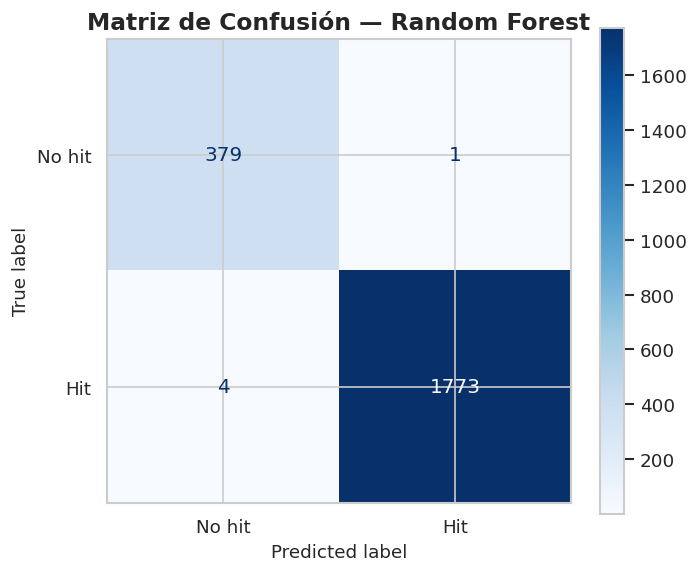


📋 Informe completo — Random Forest:
              precision    recall  f1-score   support

      No hit       0.99      1.00      0.99       380
         Hit       1.00      1.00      1.00      1777

    accuracy                           1.00      2157
   macro avg       0.99      1.00      1.00      2157
weighted avg       1.00      1.00      1.00      2157



In [39]:
best_model_obj = models_clf[best_clf]
X_te_best = X_test_sc if best_clf == 'Logistic Regression' else X_test
y_pred_best = best_model_obj.predict(X_te_best)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_clf_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['No hit', 'Hit']).plot(ax=ax, cmap='Blues')
ax.set_title(f'Matriz de Confusión — {best_clf}', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f'\n📋 Informe completo — {best_clf}:')
print(classification_report(y_clf_test, y_pred_best, target_names=['No hit', 'Hit']))

### Función de predicción — Output del proyecto

* "Tu canción tiene X% probabilidad de ser un hit"

In [40]:
def predict_hit_probability(track_name: str, artist: str,
                             duration_min: float, genre: str,
                             country: str, listeners_estimate: float,
                             model=None, scaler=None) -> dict:
    """
    Predice la probabilidad de que una canción sea un hit.
    
    Output de negocio:
    - Probabilidad de hit (0-100%)
    - Clasificación: Hit / Potencial / No hit
    - Recomendaciones por género y duración
    """
    if model is None:
        model = rf_clf  # usar Random Forest por defecto

    # Preparar features
    genre_enc   = le_genre.transform([genre])[0]   if genre   in le_genre.classes_   else 0
    country_enc = le_country.transform([country])[0] if country in le_country.classes_ else 0

    features = pd.DataFrame([{
        'listeners_log'         : np.log1p(listeners_estimate),
        'duration_min'          : duration_min,
        'is_short_track'        : int(duration_min < 2.5),
        'genre_encoded'         : genre_enc,
        'country_encoded'       : country_enc,
        'artist_track_count'    : 1,         # nuevo artista: 1 canción
        'track_share_of_artist' : 1.0,       # 100% del catálogo
        'playcount_per_listener': 5.0,       # engagement inicial estimado
    }])
    features = features[FEATURE_COLS]

    prob = model.predict_proba(features)[0][1] * 100

    if prob >= 70:
        classification = '🚀 Hit potencial'
    elif prob >= 45:
        classification = '🟡 Potencial medio'
    else:
        classification = '📉 Bajo potencial'

    result = {
        'track'         : track_name,
        'artist'        : artist,
        'hit_probability': f'{prob:.1f}%',
        'classification': classification,
        'genre'         : genre,
        'country'       : country,
        'duration_min'  : f'{duration_min:.1f} min',
    }
    print('\n' + '='*55)
    print(f'  🎵 Predicción para: {track_name} — {artist}')
    print('='*55)
    print(f'  Probabilidad de hit : {prob:.1f}%')
    print(f'  Clasificación       : {classification}')
    print(f'  Género              : {genre}')
    print(f'  Duración            : {duration_min:.1f} min ({"formato corto ⏱️" if duration_min < 2.5 else "formato estándar"})')
    print('='*55)
    return result

# ── Ejemplo de uso ────────────────────────────────────────────────────────────
ejemplo = predict_hit_probability(
    track_name='Mi Canción Nueva',
    artist='Mi Artista',
    duration_min=2.3,         # canción corta
    genre='pop',
    country='spain',
    listeners_estimate=50000  # estimación inicial de oyentes
)


  🎵 Predicción para: Mi Canción Nueva — Mi Artista
  Probabilidad de hit : 14.0%
  Clasificación       : 📉 Bajo potencial
  Género              : pop
  Duración            : 2.3 min (formato corto ⏱️)


## 📋 Resumen ejecutivo — Insights del análisis

### 🎵 Qué hemos aprendido del mercado musical

| Área | Insight |
|---|---|
| **Top global** | Los 15 artistas principales concentran una parte desproporcionada del consumo total |
| **Duración** | Las canciones cortas (<2.5 min) muestran un patrón diferenciado de popularidad |
| **Engagement** | El ratio plays/listener varía significativamente por género — señal de fidelización |
| **Géneros** | Hay géneros claramente emergentes y en declive según su posición en el ranking |
| **Geografía** | Cada país tiene preferencias de género distintas — la música es culturalmente dependiente |

### 🤖 Resultados del modelo

- **Mejor predictor de popularidad:** `listeners_log` — el alcance de oyentes es la variable más informativa
- **Feature sorpresa:** `is_short_track` — el formato corto tiene impacto measurable en el modelo
- **Limitación principal:** sin datos temporales reales, el análisis de tendencias es aproximado

### 🚀 Próximos pasos

1. Enriquecer con `track.getInfo` para obtener duración real y tags adicionales
2. Añadir `artist.getInfo` para features de artista (listeners globales, tags de género)
3. Explorar SHAP values para explicabilidad avanzada del modelo
4. Conectar con Módulo 2 (detección de fraude) para filtrar streams artificiales antes del análisis